# CircAdapt Digital Twin Calibration from CPET Data

This notebook builds **patient-specific CircAdapt digital twins** from invasive CPET / hemodynamic data.

## Direction
We are **not** predicting heart rate directly.

Instead:
- `HR` is treated as a measured/pinned input
- `CO` is pinned where available
- We will later fit the Morris-selected parameters:
  - `Am_LV`
  - `Sf_pas_LV`
  - `Sf_act_LV`
  - `Vw_LV`
  - `p0_PVR`

## Immediate goal of this notebook
Before any CircAdapt fitting, we will:
1. load the dataset,
2. standardize columns,
3. inspect what is actually available,
4. build a clean modeling dataframe.

We will move step by step and verify outputs before proceeding.

In [1]:
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

MMHG_TO_PA = 133.322
PA_TO_MMHG = 1.0 / MMHG_TO_PA
LPM_TO_M3PS = 1.0 / 60000.0
M3PS_TO_LPM = 60000.0
ML_TO_M3 = 1e-6
M3_TO_ML = 1e6

In [2]:
# Update this path only if needed
DATA_PATH = Path("SAS Database_multiple populations_for Amee Sangani.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find file: {DATA_PATH}")

print("Using data file:", DATA_PATH)

Using data file: SAS Database_multiple populations_for Amee Sangani.xlsx


In [3]:
# Load the Excel file
xls = pd.ExcelFile(DATA_PATH)
print("Sheet names:", xls.sheet_names)

raw_df = pd.read_excel(DATA_PATH, sheet_name=xls.sheet_names[0])

print("Raw shape:", raw_df.shape)
display(raw_df.head())

Sheet names: ['Sheet1']
Raw shape: (350, 110)


,study,Group,subjectid,condition,Condition_description,sex,age,height,weight,BMI,BSA,Predicted_HR,PercentMPHR,kp,watts,rpe,HR,RAP,Rvsys,Rvdias,RVEDP,PAS,PAD,mPAP,PCWP,PAPI,PVR,SBP,DBP,MAP,TPR,pasat,artsat,hgb,hct,pao2,paco2,Art O2 Content (mlO2/100mL blood),Ven O2 Content (mlO2/100mL blood),avo2,co_swan,CI_swan,SV_Swan,predictedVO2,percentpredictedvo2,VEVCO2,OUES,VO2Lmin,VO2mlkgmin,VCO2,RR,VE,RER,ETCO2,Millar file,Loops evaluated,HR.1,V max,V min,V max.1,V min.1,SV ml dp/dt,SV,CO dPdt,CI dPdt,EF,CO,CI,EF2,SW,TAU,dP/dt +,dP/dt -,PFR,PER,EDP,EDV,ESP,ESV,ESP-EDP,EDPVR,ESPVR,MI-pre,AR,MI-post,DFT,Dev. HR,Dev. dP/dt +,Dev. ESP,Dev. ESP-EDP,DS 1,DS 2,DS 3,DS 4,PE,PVA,eff,SVes,SV.1,MDP,tPER,tPFR,temp,SCI,PRSW,eSW,PVA.1,EES,EA,EESEA
0,"17-1141, healthy control",1,1,0,supine rest,1.0,45.709589,177.8,71.4,22.585759,1.877862,174.290411,36.146567,0,0,.,63,.,.,.,.,.,.,.,.,.,.,133,83,99.66667,855.507868,.,98,12.5,37.1,.,.,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.,.,.,.,.,.,NaN,oct30005,5 to 7,53.533333,170.333333,79.666667,183.333333,77.333333,90.666667,105.333333,4.846667,NaN,53,5.653333,NaN,57.666667,1420.666667,36,235,-183,1016.333333,-609.666667,5.666667,175.333333,17,89.666667,11.666667,0.031333,0.19,12.333333,-0.666667,2.666667,725.333333,1.1,0.1,0.566667,0.733333,27.5,29.433333,23.166667,33.366667,0,0,0,80.666667,86,2,289.333333,478.666667,0,1.34,8.09,NaN,NaN,NaN,NaN,NaN
1,"17-1141, healthy control",1,1,1,upright rest,1.0,45.709589,177.8,71.4,22.585759,1.877862,174.290411,36.146567,0,0,.,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133,83,99.666667,855.507868,64,100,12.5,37.1,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.513091,7.186148,0.333727,14.9,14.9,0.65,NaN,oct30011,1 to 7,69.142857,163.285714,34.285714,164,29,129,134.714286,8.91,NaN,79.142857,9.32,NaN,82.142857,3177.428571,28.571429,360.142857,-241.857143,618.857143,-1226.857143,4,126.857143,20.857143,47.714286,16.428571,0.033286,0.434714,-0.428571,-0.857143,4,537.142857,2.771429,0.7,1.9,1.942857,34.185714,28.014286,39.442857,35.342857,0,0,0,115.714286,79,1.428571,161.142857,501.142857,0,2.855714,25.121429,3186.832653,3687.184749,0.3804,0.264014,1.44083
2,"17-1141, healthy control",1,1,2,mild,1.0,45.709589,177.8,71.4,22.585759,1.877862,174.290411,44.752892,0.5,25,8,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,141,77,98.333333,849.22634,46,95,12.5,37.1,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.12696,15.783754,0.080704,19.7826,30.8087,0.71783,NaN,oct30016,1 to 6,79.933333,139.666667,57.333333,169.666667,53.833333,82.333333,115.833333,6.571667,NaN,58.833333,9.263333,NaN,68.333333,2414.333333,37.333333,436.833333,-274.5,815.333333,-1331.666667,10.333333,145.5,25.5,58.666667,15.166667,0.071333,0.435833,14.5,1.833333,3.166667,429.333333,0.6,1.7,1.633333,2.966667,33.2,30.6,43.1,35.15,0,0,0,80.833333,86.666667,5.166667,182.666667,440.666667,0,3.001667,16.613333,2417.240000,3163.224704,0.3886,0.294231,1.320732
3,"17-1141, healthy control",1,1,3,moderate,1.0,45.709589,177.8,71.4,22.585759,1.877862,174.290411,54.506728,1,50,10,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,146,70,95.333333,681.662446,37,97,12.5,37.1,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.52974,21.42493,1.21865,24.9217,45.8391,0.79739,NaN,oct30017,1 to 6,97.3,141,63,175.333333,60,77.666667,114.666667,7.57,NaN,55.333333,11.188333,NaN,65.5,2944.666667,32.666667,569.333333,-429.5,873.166667,-1456.666667,13,145.833333,36.166667,64,23.166667,0.089,0.563833,11,1,3.166667,324,0.583333,2.783333,1.283333,4.733333,33.583333,31.65,40.316667,36.166667,0,0,0,76.833333,82,6.833333,177.333333,404.666667,0,3.905,20.191667,2944.618056,4104.559922,0.5229,0.441057,1.185561
4,"17-1141, healthy control",1,1,4,peak,1.0,45.709589,177.8,71.4,22.585759,1.877862,174.290411,90.653295,4.5,225,17,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,186,75,112,467.396974,27,100,12.5,37.1,.,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.44625,48.266807,3.87075,1.1225,131.15,1.1225,NaN,oct30020,"1252, 1255",136.35,148.5,21,150,9.5,127.5,140.5,17.375,NaN,85.5,19.17,

In [4]:
def standardize_column_name(col: str) -> str:
    col = str(col).strip()
    col = col.replace("%", "pct")
    col = col.replace("/", "_per_")
    col = col.replace("+", "_plus")
    col = col.replace("-", "_minus")
    col = col.replace("(", "_")
    col = col.replace(")", "_")
    col = re.sub(r"[^\w\s\.]+", "", col)
    col = re.sub(r"\s+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_").lower()

raw_df = raw_df.copy()
raw_df.columns = [standardize_column_name(c) for c in raw_df.columns]

print("Standardized shape:", raw_df.shape)
print("\nFirst 110 standardized columns:")
print(list(raw_df.columns))

Standardized shape: (350, 110)

First 110 standardized columns:
['study', 'group', 'subjectid', 'condition', 'condition_description', 'sex', 'age', 'height', 'weight', 'bmi', 'bsa', 'predicted_hr', 'percentmphr', 'kp', 'watts', 'rpe', 'hr', 'rap', 'rvsys', 'rvdias', 'rvedp', 'pas', 'pad', 'mpap', 'pcwp', 'papi', 'pvr', 'sbp', 'dbp', 'map', 'tpr', 'pasat', 'artsat', 'hgb', 'hct', 'pao2', 'paco2', 'art_o2_content_mlo2_per_100ml_blood', 'ven_o2_content_mlo2_per_100ml_blood', 'avo2', 'co_swan', 'ci_swan', 'sv_swan', 'predictedvo2', 'percentpredictedvo2', 'vevco2', 'oues', 'vo2lmin', 'vo2mlkgmin', 'vco2', 'rr', 've', 'rer', 'etco2', 'millar_file', 'loops_evaluated', 'hr.1', 'v_max', 'v_min', 'v_max.1', 'v_min.1', 'sv_ml_dp_per_dt', 'sv', 'co_dpdt', 'ci_dpdt', 'ef', 'co', 'ci', 'ef2', 'sw', 'tau', 'dp_per_dt_plus', 'dp_per_dt_minus', 'pfr', 'per', 'edp', 'edv', 'esp', 'esv', 'esp_minusedp', 'edpvr', 'espvr', 'mi_minuspre', 'ar', 'mi_minuspost', 'dft', 'dev._hr', 'dev._dp_per_dt_plus', 'dev._

## Step 2: Build modeling dataframe

We now extract only the relevant variables for digital twin modeling.

Key decisions:
- Use `co_swan` as primary CO (fallback to `co` if missing)
- Build a robust `patient_id`
- Use `condition_description` for stage classification
- Create `is_rest` flag

In [5]:
df = raw_df.copy()

# Create a robust patient_id (important)
df["patient_id"] = (
    df["study"].astype(str).str.strip() + "_" +
    df["subjectid"].astype(str).str.strip()
)

# Standardize condition label
df["condition_label"] = df["condition_description"].astype(str).str.strip().str.lower()

display(df[["study", "subjectid", "patient_id", "condition_label"]].head())

,study,subjectid,patient_id,condition_label
0,"17-1141, healthy control",1,"17-1141, healthy control_1",supine rest
1,"17-1141, healthy control",1,"17-1141, healthy control_1",upright rest
2,"17-1141, healthy control",1,"17-1141, healthy control_1",mild
3,"17-1141, healthy control",1,"17-1141, healthy control_1",moderate
4,"17-1141, healthy control",1,"17-1141, healthy control_1",peak


In [6]:
# Choose CO signal (prefer Swan, fallback to CO)
df["co_final"] = df["co_swan"]

fallback_mask = df["co_final"].isna() & df["co"].notna()
df.loc[fallback_mask, "co_final"] = df.loc[fallback_mask, "co"]

# Quick sanity check
display(df[["co_swan", "co", "co_final"]].head(10))

,co_swan,co,co_final
0,NaN,5.653333,5.653333
1,NaN,9.32,9.32
2,NaN,9.263333,9.263333
3,NaN,11.188333,11.188333
4,NaN,19.17,19.17
5,8.213702,NaN,8.213702
6,NaN,6.94,6.94
7,NaN,13.1925,13.1925
8,NaN,16.707143,16.707143
9,NaN,23.005,23.005


In [7]:
# Define rest flag
def is_rest_condition(label):
    if pd.isna(label):
        return False
    label = str(label).lower()
    return ("rest" in label)

df["is_rest"] = df["condition_label"].apply(is_rest_condition)

display(df[["condition_label", "is_rest"]].drop_duplicates())

,condition_label,is_rest
0,supine rest,True
1,upright rest,True
2,mild,False
3,moderate,False
4,peak,False
103,noninvasive_normoxia_upright_rest,True
104,noninvasive_normoxia_peak_exercise,False
105,noninvasive_hypoxia_fio21,False
106,noninvasive_hypoxia_fio17,False
107,noninvasive_hypoxia_fio15,False


In [8]:
# Build modeling dataframe (core variables only)

model_df = pd.DataFrame({
    "patient_id": df["patient_id"],
    "condition": df["condition_label"],
    "is_rest": df["is_rest"],

    # pinned inputs
    "hr_bpm": df["hr"],
    "co_l_min": df["co_final"],

    # targets
    "map_mmhg": df["map"],
    "ef_pct": df["ef"],
    "edv_ml": df["edv"],
    "esv_ml": df["esv"],
    "pcwp_mmhg": df["pcwp"],

    # optional extras
    "sbp_mmhg": df["sbp"],
    "dbp_mmhg": df["dbp"],
    "rap_mmhg": df["rap"],
    "mpap_mmhg": df["mpap"],

    # demographics
    "age": df["age"],
    "sex": df["sex"],
    "bsa": df["bsa"],
})

print("Model df shape:", model_df.shape)
display(model_df.head())

Model df shape: (350, 17)


,patient_id,condition,is_rest,hr_bpm,co_l_min,map_mmhg,ef_pct,edv_ml,esv_ml,pcwp_mmhg,sbp_mmhg,dbp_mmhg,rap_mmhg,mpap_mmhg,age,sex,bsa
0,"17-1141, healthy control_1",supine rest,True,63,5.653333,99.66667,53,175.333333,89.666667,.,133,83,.,.,45.709589,1.0,1.877862
1,"17-1141, healthy control_1",upright rest,True,63,9.32,99.666667,79.142857,126.857143,47.714286,NaN,133,83,NaN,NaN,45.709589,1.0,1.877862
2,"17-1141, healthy control_1",mild,False,78,9.263333,98.333333,58.833333,145.5,58.666667,NaN,141,77,NaN,NaN,45.709589,1.0,1.877862
3,"17-1141, healthy control_1",moderate,False,95,11.188333,95.333333,55.333333,145.833333,64,NaN,146,70,NaN,NaN,45.709589,1.0,1.877862
4,"17-1141, healthy control_1",peak,False,158,19.17,112,85.5,109,34,NaN,186,75,NaN,NaN,45.709589,1.0,1.877862


In [9]:
# Clean non-numeric placeholders (VERY IMPORTANT)

def clean_numeric_column(col):
    return pd.to_numeric(col, errors="coerce")

for c in ["pcwp_mmhg", "rap_mmhg", "mpap_mmhg"]:
    if c in model_df.columns:
        model_df[c] = clean_numeric_column(model_df[c])

# Verify
display(model_df[["pcwp_mmhg", "rap_mmhg", "mpap_mmhg"]].head(10))

,pcwp_mmhg,rap_mmhg,mpap_mmhg
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,5.0,2.0,11.666
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [10]:
# Add completeness flags

model_df["has_hr"] = model_df["hr_bpm"].notna()
model_df["has_co"] = model_df["co_l_min"].notna()
model_df["has_map"] = model_df["map_mmhg"].notna()
model_df["has_ef"] = model_df["ef_pct"].notna()
model_df["has_edv"] = model_df["edv_ml"].notna()
model_df["has_esv"] = model_df["esv_ml"].notna()
model_df["has_pcwp"] = model_df["pcwp_mmhg"].notna()

# Core targets (without PCWP)
core_cols = ["map_mmhg", "ef_pct", "edv_ml", "esv_ml"]

model_df["n_core_targets"] = model_df[core_cols].notna().sum(axis=1)

display(model_df.head())

,patient_id,condition,is_rest,hr_bpm,co_l_min,map_mmhg,ef_pct,edv_ml,esv_ml,pcwp_mmhg,sbp_mmhg,dbp_mmhg,rap_mmhg,mpap_mmhg,age,sex,bsa,has_hr,has_co,has_map,has_ef,has_edv,has_esv,has_pcwp,n_core_targets
0,"17-1141, healthy control_1",supine rest,True,63,5.653333,99.66667,53,175.333333,89.666667,NaN,133,83,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4
1,"17-1141, healthy control_1",upright rest,True,63,9.32,99.666667,79.142857,126.857143,47.714286,NaN,133,83,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4
2,"17-1141, healthy control_1",mild,False,78,9.263333,98.333333,58.833333,145.5,58.666667,NaN,141,77,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4
3,"17-1141, healthy control_1",moderate,False,95,11.188333,95.333333,55.333333,145.833333,64,NaN,146,70,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4
4,"17-1141, healthy control_1",peak,False,158,19.17,112,85.5,109,34,NaN,186,75,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4


In [11]:
# Summary statistics

print("Total rows:", len(model_df))
print("Unique patients:", model_df["patient_id"].nunique())

print("\nMissingness:")
display(model_df.isna().mean().sort_values())

Total rows: 350
Unique patients: 44

Missingness:


patient_id        0.000000
condition         0.000000
is_rest           0.000000
age               0.000000
has_map           0.000000
has_co            0.000000
has_hr            0.000000
n_core_targets    0.000000
has_pcwp          0.000000
has_esv           0.000000
has_edv           0.000000
has_ef            0.000000
bsa               0.000000
map_mmhg          0.005714
dbp_mmhg          0.005714
sbp_mmhg          0.005714
co_l_min          0.005714
esv_ml            0.008571
edv_ml            0.008571
ef_pct            0.008571
hr_bpm            0.014286
sex               0.037143
mpap_mmhg         0.771429
rap_mmhg          0.771429
pcwp_mmhg         0.774286
dtype: float64

In [12]:
# Patient-level summary

patient_summary = model_df.groupby("patient_id").agg(
    n_rows=("patient_id", "size"),
    n_rest=("is_rest", "sum"),
    max_targets=("n_core_targets", "max"),
    mean_targets=("n_core_targets", "mean"),
    has_co=("has_co", "max"),
    has_pcwp=("has_pcwp", "max")
).reset_index()

display(patient_summary.sort_values("max_targets", ascending=False).head(20))

,patient_id,n_rows,n_rest,max_targets,mean_targets,has_co,has_pcwp
0,"17-1141, LVAD_102",5,2,4,4.0,True,True
1,"17-1141, LVAD_104",5,2,4,4.0,True,True
2,"17-1141, LVAD_105",5,2,4,4.0,True,True
3,"17-1141, LVAD_106",5,2,4,4.0,True,True
4,"17-1141, LVAD_107",5,2,4,3.8,True,False
5,"17-1141, LVAD_108",5,2,4,4.0,True,True
6,"17-1141, LVAD_109",5,2,4,4.0,True,True
7,"17-1141, LVAD_110",5,2,4,4.0,True,True
8,"17-1141, LVAD_111",5,2,4,4.0,True,False
9,"17-1141, LVAD_112",5,2,4,4.0,True,True


In [13]:
# Score patients for pilot selection

patient_summary["score"] = (
    2 * patient_summary["n_rest"] +
    1.5 * patient_summary["max_targets"] +
    0.5 * patient_summary["n_rows"] +
    1.0 * patient_summary["has_co"].astype(int)
)

display(patient_summary.sort_values("score", ascending=False).head(20))

,patient_id,n_rows,n_rest,max_targets,mean_targets,has_co,has_pcwp,score
34,"21-4354, hypoxia_1",20,9,4,4.0,True,True,35.0
37,"21-4354, hypoxia_3",18,9,4,4.0,True,True,34.0
42,"21-4354, hypoxia_8",18,9,4,4.0,True,True,34.0
38,"21-4354, hypoxia_4",18,9,4,4.0,True,True,34.0
39,"21-4354, hypoxia_5",18,9,4,4.0,True,True,34.0
43,"21-4354, hypoxia_9",18,9,4,4.0,True,True,34.0
41,"21-4354, hypoxia_7",18,9,4,4.0,True,True,34.0
40,"21-4354, hypoxia_6",18,9,4,4.0,True,True,34.0
36,"21-4354, hypoxia_2",18,9,4,4.0,True,True,34.0
35,"21-4354, hypoxia_10",18,9,4,4.0,True,True,34.0


## CircAdapt Fitting

In [14]:
# Rows usable for fitting (core targets only)

model_df["usable_for_fit"] = (
    model_df["has_map"] &
    model_df["has_ef"] &
    model_df["has_edv"] &
    model_df["has_esv"] &
    model_df["has_hr"] &
    model_df["has_co"]
)

print("Usable rows:", model_df["usable_for_fit"].sum(), "/", len(model_df))

Usable rows: 341 / 350


In [15]:
# Rest rows usable for initial fitting

rest_df = model_df[
    (model_df["is_rest"]) &
    (model_df["usable_for_fit"])
].copy()

print("Rest rows usable:", len(rest_df))
print("Unique patients (rest):", rest_df["patient_id"].nunique())

display(rest_df.head())

Rest rows usable: 154
Unique patients (rest): 43


,patient_id,condition,is_rest,hr_bpm,co_l_min,map_mmhg,ef_pct,edv_ml,esv_ml,pcwp_mmhg,sbp_mmhg,dbp_mmhg,rap_mmhg,mpap_mmhg,age,sex,bsa,has_hr,has_co,has_map,has_ef,has_edv,has_esv,has_pcwp,n_core_targets,usable_for_fit
0,"17-1141, healthy control_1",supine rest,True,63,5.653333,99.66667,53,175.333333,89.666667,NaN,133,83,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4,True
1,"17-1141, healthy control_1",upright rest,True,63,9.32,99.666667,79.142857,126.857143,47.714286,NaN,133,83,NaN,NaN,45.709589,1.0,1.877862,True,True,True,True,True,True,False,4,True
6,"17-1141, healthy control_3",upright rest,True,63,6.94,96.666667,57.142857,193.142857,92.142857,NaN,142,74,NaN,NaN,26.364384,1.0,1.898259,True,True,True,True,True,True,False,4,True
10,"17-1141, healthy control_4",supine rest,True,62,7.1106,97.3333,59.166667,145,54,NaN,124,84,NaN,NaN,26.652055,1.0,2.258512,True,True,True,True,True,True,False,4,True
11,"17-1141, healthy control_4",upright rest,True,62,6.36,104,71.4,97.8,21.4,NaN,136,88,NaN,NaN,26.652055,1.0,2.258512,True,True,True,True,True,True,False,4,True


## Step 4: CircAdapt integration

In this section we:
1. confirm that CircAdapt imports correctly,
2. create a model instance,
3. probe the available API,
4. define output extraction helpers.

At this stage, we are **not fitting yet**.
We are only making sure we can safely communicate with the model.

In [16]:
import circadapt
print("CircAdapt imported successfully.")
print("circadapt module:", circadapt)

CircAdapt imported successfully.
circadapt module: <module 'circadapt' from 'C:\\Users\\Sohan Kshirsagar\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\circadapt\\__init__.py'>


In [17]:
# Try to inspect what constructors / classes are available
print("Top-level names in circadapt:")
print([name for name in dir(circadapt) if not name.startswith("_")][:100])

Top-level names in circadapt:
['CircAdapt', 'CorruptBuild', 'DEFAULT_PATH_TO_CIRCADAPT', 'ModelCrashed', 'TriggerNotFound', 'VanOsta2023', 'VanOsta2024', 'adapt', 'circadapt', 'components', 'error', 'get_default_path_to_circadapt', 'load_plugin_components', 'matlab', 'model', 'os', 'pathlib', 'platform', 'plot', 'smart_components', 'smart_components_circulation', 'smart_components_heart', 'version']


In [18]:
# Try a few common constructor patterns carefully.
# We only want to discover how your installed CircAdapt is initialized.

model = None
constructor_attempts = []

for expr in [
    "circadapt.VanOsta2024()",
    "circadapt.Model()",
    "circadapt.CircAdapt()",
]:
    try:
        model = eval(expr)
        constructor_attempts.append((expr, "SUCCESS"))
        print(f"SUCCESS: {expr}")
        break
    except Exception as e:
        constructor_attempts.append((expr, repr(e)))
        print(f"FAILED: {expr}")
        print("  ", repr(e))

if model is None:
    print("\nNo constructor worked yet. Constructor attempts:")
    for item in constructor_attempts:
        print(item)
else:
    print("\nModel object created:")
    print(type(model))

SUCCESS: circadapt.VanOsta2024()

Model object created:
<class 'circadapt.model.vanosta2024.VanOsta2024'>


In [19]:
# Probe the model API a bit
if model is not None:
    print("Type:", type(model))
    print("\nModel dir preview:")
    print([name for name in dir(model) if not name.startswith("_")][:100])
else:
    print("Model is None. We need to inspect the available circadapt constructors first.")

Type: <class 'circadapt.model.vanosta2024.VanOsta2024'>

Model dir preview:
['adapt', 'adapt_exercise', 'adapt_rest', 'add', 'add_component', 'add_smart_component', 'assert_1_beat', 'assert_test_settings', 'build', 'build_artven', 'build_heart', 'build_pfc', 'build_timings', 'calculate_and_set_matrix', 'check_build', 'components', 'copy', 'get', 'get_adapt_options', 'get_matrix', 'get_model_reference', 'get_unittest_results', 'get_unittest_targets', 'health_check', 'install', 'is_stable', 'is_success', 'load', 'load_plugin_components', 'load_reference', 'model_export', 'model_import', 'path', 'plot', 'plot_extended', 'run', 'save', 'set', 'set_component', 'set_reference', 'stepper', 'trigger']


## Step 5: Safe CircAdapt adapter

In this section we:
1. create a fresh VanOsta2024 model,
2. run it to a stable state,
3. define helper functions to extract the main outputs we care about.

We are still not fitting parameters yet.
We are only building a reliable interface.

In [20]:
def create_base_model():
    """
    Create a fresh CircAdapt VanOsta2024 model.
    """
    m = circadapt.VanOsta2024()
    return m

base_model = create_base_model()
print("Created base model:", type(base_model))

Created base model: <class 'circadapt.model.vanosta2024.VanOsta2024'>


In [21]:
# Inspect a few important baseline values / paths
# This helps us verify the get(...) interface and signal naming.

candidate_paths = [
    "Model.t",
    "Model.PFC.q0",
    "Model.PFC.p0",
    "Model.Peri.SyArt.p",
    "Model.Peri.SyVenRa.q",
    "Model.Heart.Lv.V",
    "Model.Heart.La.p",
]

for p in candidate_paths:
    try:
        val = base_model.get(p)
        print(f"{p}: SUCCESS -> type={type(val)}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.t: FAILED -> ValueError('Parameter "Model.parameter_type:t" not found. ')
Model.PFC.q0: SUCCESS -> type=<class 'float'>
Model.PFC.p0: SUCCESS -> type=<class 'float'>
Model.Peri.SyArt.p: FAILED -> ValueError('Parameter "Model.Peri.SyArt.parameter_type:p" not found. ')
Model.Peri.SyVenRa.q: SUCCESS -> type=<class 'numpy.ndarray'>
Model.Heart.Lv.V: FAILED -> ValueError('Parameter "Model.Heart.Lv.parameter_type:V" not found. ')
Model.Heart.La.p: FAILED -> ValueError('Parameter "Model.Heart.La.parameter_type:p" not found. ')


In [22]:
def run_model_to_steady_state(model, n_beats=20, dt=None, verbose=True):
    """
    Run a CircAdapt model forward and check stability.
    Keep this simple first.
    """
    try:
        if dt is None:
            model.run(n_beats)
        else:
            model.run(n_beats, dt=dt)

        stable = None
        try:
            stable = model.is_stable()
        except Exception:
            stable = "unknown"

        if verbose:
            print(f"Run completed for {n_beats} beats. Stable: {stable}")

        return model

    except Exception as e:
        print("Model run failed:", repr(e))
        raise

# Test run
test_model = create_base_model()
test_model = run_model_to_steady_state(test_model, n_beats=20)

Run completed for 20 beats. Stable: True


In [23]:
# After running, probe candidate output paths.
# We are trying to identify the exact paths for our main observables.

test_paths = [
    "Model.Peri.SyArt.p",
    "Model.Peri.SyVenRa.q",
    "Model.Heart.La.p",
    "Model.Heart.Lv.V",
    "Model.Heart.Lv.p",
    "Model.Heart.SyArt.p",   # just in case
]

for p in test_paths:
    try:
        val = test_model.get(p)
        if hasattr(val, "__len__") and not isinstance(val, (str, bytes)):
            try:
                print(f"{p}: len={len(val)}, first few={np.array(val).flatten()[:5]}")
            except Exception:
                print(f"{p}: SUCCESS but preview failed, type={type(val)}")
        else:
            print(f"{p}: scalar/value={val}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.Peri.SyArt.p: FAILED -> ValueError('Parameter "Model.Peri.SyArt.parameter_type:p" not found. ')
Model.Peri.SyVenRa.q: len=426, first few=[0.00014949 0.00014811 0.00014671 0.00014529 0.00014384]
Model.Heart.La.p: FAILED -> ValueError('Parameter "Model.Heart.La.parameter_type:p" not found. ')
Model.Heart.Lv.V: FAILED -> ValueError('Parameter "Model.Heart.Lv.parameter_type:V" not found. ')
Model.Heart.Lv.p: FAILED -> ValueError('Parameter "Model.Heart.Lv.parameter_type:p" not found. ')
Model.Heart.SyArt.p: FAILED -> ValueError('Parameter "Model.Heart.SyArt.parameter_type:p" not found. ')


## Step 6: Verify known CircAdapt paths from prior notebook

The previous notebook already revealed some correct CircAdapt paths.

In this section we verify those exact paths directly, instead of trying to inspect
the full component tree.

In [24]:
# Verify the known working arterial pressure path from the old notebook

try:
    p_syart = np.array(test_model.get("Model.SyArt.p", list), dtype=float)
    print("SUCCESS: Model.SyArt.p")
    print("Length:", len(p_syart))
    print("First 10 values:", p_syart[:10])
    print("Mean arterial pressure [Pa]:", float(np.mean(p_syart)))
    print("Mean arterial pressure [mmHg]:", float(np.mean(p_syart) / MMHG_TO_PA))
except Exception as e:
    print("FAILED: Model.SyArt.p")
    print(repr(e))

SUCCESS: Model.SyArt.p
Length: 426
First 10 values: [10950.26661245 10936.43419959 10922.62714625 10908.84478776
 10895.08708623 10881.3540056  10867.64551288 10853.9615794
 10840.30218213 10826.66730484]
Mean arterial pressure [Pa]: 12197.072164265286
Mean arterial pressure [mmHg]: 91.4858175264794


In [25]:
# Verify the known working venous return flow path

try:
    q_ven = np.array(test_model.get("Model.Peri.SyVenRa.q", list), dtype=float)
    print("SUCCESS: Model.Peri.SyVenRa.q")
    print("Length:", len(q_ven))
    print("First 10 values:", q_ven[:10])
    print("Mean flow [m^3/s]:", float(np.mean(q_ven)))
    print("Mean flow [L/min]:", float(np.mean(q_ven) * M3PS_TO_LPM))
except Exception as e:
    print("FAILED: Model.Peri.SyVenRa.q")
    print(repr(e))

SUCCESS: Model.Peri.SyVenRa.q
Length: 426
First 10 values: [0.00014949 0.00014811 0.00014671 0.00014529 0.00014384 0.00014237
 0.00014086 0.00013931 0.00013769 0.00013599]
Mean flow [m^3/s]: 8.515138424038254e-05
Mean flow [L/min]: 5.109083054422952


In [26]:
# Probe the key parameter paths we will later use for fitting

candidate_param_paths = [
    "Model.PFC.q0",
    "Model.PFC.p0",
    "Model.Peri.TriSeg.wLv.pLv0.Sf_pas",
    "Model.Peri.TriSeg.wLv.pLv0.Sf_act",
    "Model.Peri.TriSeg.wLv.V_wall",
    "Model.Peri.TriSeg.wLv.Am_ref",
]

for p in candidate_param_paths:
    try:
        val = test_model.get(p)
        print(f"{p}: SUCCESS -> {val}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.PFC.q0: SUCCESS -> 8.5e-05
Model.PFC.p0: SUCCESS -> 12200.0
Model.Peri.TriSeg.wLv.pLv0.Sf_pas: SUCCESS -> 731.24545453
Model.Peri.TriSeg.wLv.pLv0.Sf_act: SUCCESS -> 120000.0
Model.Peri.TriSeg.wLv.V_wall: SUCCESS -> 7.35720515e-05
Model.Peri.TriSeg.wLv.Am_ref: FAILED -> ValueError('Parameter "Model.Peri.TriSeg.wLv.parameter_type:Am_ref" not found. ')


In [27]:
def extract_basic_outputs(model):
    """
    Extract outputs that we already know how to obtain safely.
    For now:
    - MAP, SBP, DBP from Model.SyArt.p
    - CO from Model.Peri.SyVenRa.q
    """
    p_syart = np.array(model.get("Model.SyArt.p", list), dtype=float)
    q_ven = np.array(model.get("Model.Peri.SyVenRa.q", list), dtype=float)

    outputs = {
        "map_mmhg": float(np.mean(p_syart) / MMHG_TO_PA),
        "sbp_mmhg": float(np.max(p_syart) / MMHG_TO_PA),
        "dbp_mmhg": float(np.min(p_syart) / MMHG_TO_PA),
        "co_l_min": float(np.mean(q_ven) * M3PS_TO_LPM),
    }
    return outputs

baseline_outputs = extract_basic_outputs(test_model)
baseline_outputs

{'map_mmhg': 91.4858175264794,
 'sbp_mmhg': 118.92687085185881,
 'dbp_mmhg': 70.0828056790457,
 'co_l_min': 5.109083054422952}

## Step 7: Probe remaining LV geometry and cavity paths

Known:
- `Sf_pas_LV` works
- `Sf_act_LV` works
- `V_wall` works

Unknown:
- `Am_LV`
- LV cavity volume path for EDV/ESV
- LA pressure path for PCWP proxy

We now probe likely path variants carefully.

In [28]:
# Probe likely alternatives for LV reference area / geometry

am_candidates = [
    "Model.Peri.TriSeg.wLv.Am_ref",
    "Model.Peri.TriSeg.wLv.Am",
    "Model.Peri.TriSeg.wLv.Am0",
    "Model.Peri.TriSeg.wLv.pLv0.Am_ref",
    "Model.Peri.TriSeg.wLv.pLv0.Am",
    "Model.Peri.TriSeg.wLv.pLv0.Am0",
    "Model.Peri.TriSeg.cLv.Am_ref",
    "Model.Peri.TriSeg.cLv.Am",
]

for p in am_candidates:
    try:
        val = test_model.get(p)
        print(f"{p}: SUCCESS -> {val}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.Peri.TriSeg.wLv.Am_ref: FAILED -> ValueError('Parameter "Model.Peri.TriSeg.wLv.parameter_type:Am_ref" not found. ')
Model.Peri.TriSeg.wLv.Am: SUCCESS -> [0.01042019 0.01042526 0.01043027 0.01043524 0.01044017 0.01044507
 0.01044992 0.01045475 0.01045955 0.01046433 0.01046908 0.01047381
 0.01047851 0.0104832  0.01048786 0.0104925  0.01049711 0.0105017
 0.01050626 0.0105108  0.01051532 0.01051982 0.0105243  0.01052879
 0.0105333  0.01053785 0.01054247 0.01054719 0.01055205 0.01055709
 0.01056237 0.01056793 0.01057382 0.01058011 0.01058685 0.01059408
 0.01060187 0.01061026 0.01061928 0.01062896 0.01063934 0.01065042
 0.0106622  0.01067468 0.01068785 0.01070166 0.0107161  0.0107311
 0.01074664 0.01076265 0.01077907 0.01079585 0.01081293 0.01083025
 0.01084774 0.01086537 0.01088307 0.01090079 0.0109185  0.01093615
 0.0109537  0.01097112 0.01098838 0.01100544 0.01102229 0.0110389
 0.01105524 0.0110713  0.01108705 0.01110249 0.01111758 0.01113231
 0.01114665 0.01116057 0.01117404 0.0111

In [29]:
# Probe likely LV cavity volume paths for EDV / ESV

lv_volume_candidates = [
    "Model.cLv.V",
    "Model.Cavity.cLv.V",
    "Model.Cavity.Lv.V",
    "Model.Lv.V",
    "Model.Peri.cLv.V",
    "Model.Peri.TriSeg.cLv.V",
    "Model.Peri.TriSeg.pLv0.V",
]

for p in lv_volume_candidates:
    try:
        val = np.array(test_model.get(p, list), dtype=float)
        print(f"{p}: SUCCESS len={len(val)}, head={val[:5]}, min={val.min()}, max={val.max()}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.cLv.V: FAILED -> ValueError('Model.cLv.V not found.')
Model.Cavity.cLv.V: FAILED -> ValueError('Model.Cavity.cLv.V not found.')
Model.Cavity.Lv.V: FAILED -> ValueError('Model.Cavity.Lv.V not found.')
Model.Lv.V: FAILED -> ValueError('Model.Lv.V not found.')
Model.Peri.cLv.V: FAILED -> ValueError('Model.Peri.cLv.V not found.')
Model.Peri.TriSeg.cLv.V: SUCCESS len=426, head=[0.00010203 0.00010213 0.00010223 0.00010233 0.00010243], min=4.800515204062419e-05, max=0.00012025899748271425
Model.Peri.TriSeg.pLv0.V: FAILED -> ValueError('Model.Peri.TriSeg.pLv0.V not found.')


In [30]:
# Probe likely left atrial pressure paths for PCWP proxy

la_pressure_candidates = [
    "Model.cLa.p",
    "Model.Cavity.cLa.p",
    "Model.Cavity.La.p",
    "Model.La.p",
    "Model.Peri.cLa.p",
    "Model.Peri.TriSeg.cLa.p",
    "Model.Peri.La.p",
]

for p in la_pressure_candidates:
    try:
        val = np.array(test_model.get(p, list), dtype=float)
        print(f"{p}: SUCCESS len={len(val)}, head={val[:5]}, mean_mmHg={np.mean(val)/MMHG_TO_PA}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.cLa.p: FAILED -> ValueError('Model.cLa.p not found.')
Model.Cavity.cLa.p: FAILED -> ValueError('Model.Cavity.cLa.p not found.')
Model.Cavity.La.p: FAILED -> ValueError('Model.Cavity.La.p not found.')
Model.La.p: FAILED -> ValueError('Model.La.p not found.')
Model.Peri.cLa.p: FAILED -> ValueError('Model.Peri.cLa.p not found.')
Model.Peri.TriSeg.cLa.p: FAILED -> ValueError('Model.Peri.TriSeg.cLa.p not found.')
Model.Peri.La.p: SUCCESS len=426, head=[895.61252933 901.37485679 906.71027841 911.62195009 916.11479407], mean_mmHg=7.182844516215154


In [31]:
# Probe likely LV pressure paths (useful for sanity checking later)

lv_pressure_candidates = [
    "Model.cLv.p",
    "Model.Cavity.cLv.p",
    "Model.Cavity.Lv.p",
    "Model.Lv.p",
    "Model.Peri.cLv.p",
    "Model.Peri.TriSeg.cLv.p",
]

for p in lv_pressure_candidates:
    try:
        val = np.array(test_model.get(p, list), dtype=float)
        print(f"{p}: SUCCESS len={len(val)}, head={val[:5]}, mean_mmHg={np.mean(val)/MMHG_TO_PA}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.cLv.p: FAILED -> ValueError('Model.cLv.p not found.')
Model.Cavity.cLv.p: FAILED -> ValueError('Model.Cavity.cLv.p not found.')
Model.Cavity.Lv.p: FAILED -> ValueError('Model.Cavity.Lv.p not found.')
Model.Lv.p: FAILED -> ValueError('Model.Lv.p not found.')
Model.Peri.cLv.p: FAILED -> ValueError('Model.Peri.cLv.p not found.')
Model.Peri.TriSeg.cLv.p: SUCCESS len=426, head=[925.4749737  927.74020914 929.98641025 932.21538053 934.42866316], mean_mmHg=41.48733595662329


## Step 8: Define output extraction and parameter interface

We now define:
- extraction of model outputs needed for fitting
- getter for the 5 Morris-selected parameters
- setter for the 5 Morris-selected parameters

This is the first complete interface between the dataset and CircAdapt.

In [32]:
def extract_outputs(model):
    """
    Extract the core outputs needed for digital twin fitting.

    Returns:
        dict with:
        - map_mmhg
        - sbp_mmhg
        - dbp_mmhg
        - co_l_min
        - edv_ml
        - esv_ml
        - ef_pct
        - pcwp_mmhg
    """
    p_syart = np.array(model.get("Model.SyArt.p", list), dtype=float)
    q_ven = np.array(model.get("Model.Peri.SyVenRa.q", list), dtype=float)
    v_lv = np.array(model.get("Model.Peri.TriSeg.cLv.V", list), dtype=float)
    p_la = np.array(model.get("Model.Peri.La.p", list), dtype=float)

    edv_ml = float(np.max(v_lv) * M3_TO_ML)
    esv_ml = float(np.min(v_lv) * M3_TO_ML)

    if edv_ml > 0:
        ef_pct = float((edv_ml - esv_ml) / edv_ml * 100.0)
    else:
        ef_pct = np.nan

    outputs = {
        "map_mmhg": float(np.mean(p_syart) / MMHG_TO_PA),
        "sbp_mmhg": float(np.max(p_syart) / MMHG_TO_PA),
        "dbp_mmhg": float(np.min(p_syart) / MMHG_TO_PA),
        "co_l_min": float(np.mean(q_ven) * M3PS_TO_LPM),
        "edv_ml": edv_ml,
        "esv_ml": esv_ml,
        "ef_pct": ef_pct,
        "pcwp_mmhg": float(np.mean(p_la) / MMHG_TO_PA),   # LA pressure proxy
    }
    return outputs

baseline_outputs = extract_outputs(test_model)
baseline_outputs

{'map_mmhg': 91.4858175264794,
 'sbp_mmhg': 118.92687085185881,
 'dbp_mmhg': 70.0828056790457,
 'co_l_min': 5.109083054422952,
 'edv_ml': 120.25899748271425,
 'esv_ml': 48.00515204062419,
 'ef_pct': 60.08186244233049,
 'pcwp_mmhg': 7.182844516215154}

In [33]:
def get_theta(model):
    """
    Read the 5 Morris-selected free parameters from CircAdapt.
    """
    theta = {
        "Am_LV": float(model.get("Model.Peri.TriSeg.wLv.pLv0.Am_ref")),
        "Sf_pas_LV": float(model.get("Model.Peri.TriSeg.wLv.pLv0.Sf_pas")),
        "Sf_act_LV": float(model.get("Model.Peri.TriSeg.wLv.pLv0.Sf_act")),
        "Vw_LV": float(model.get("Model.Peri.TriSeg.wLv.V_wall")),
        "p0_PVR": float(model.get("Model.PFC.p0")),
    }
    return theta

theta0 = get_theta(test_model)
theta0

{'Am_LV': 0.00966859,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 120000.0,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 12200.0}

In [34]:
def set_theta(model, theta):
    """
    Set the 5 Morris-selected free parameters in CircAdapt.

    theta keys:
    - Am_LV
    - Sf_pas_LV
    - Sf_act_LV
    - Vw_LV
    - p0_PVR
    """
    model.set("Model.Peri.TriSeg.wLv.pLv0.Am_ref", float(theta["Am_LV"]))
    model.set("Model.Peri.TriSeg.wLv.pLv0.Sf_pas", float(theta["Sf_pas_LV"]))
    model.set("Model.Peri.TriSeg.wLv.pLv0.Sf_act", float(theta["Sf_act_LV"]))
    model.set("Model.Peri.TriSeg.wLv.V_wall", float(theta["Vw_LV"]))
    model.set("Model.PFC.p0", float(theta["p0_PVR"]))
    return model

# quick round-trip test
tmp_model = create_base_model()
tmp_model = run_model_to_steady_state(tmp_model, n_beats=20, verbose=False)

theta_before = get_theta(tmp_model)

theta_test = theta_before.copy()
theta_test["p0_PVR"] = theta_before["p0_PVR"] * 1.05

tmp_model = set_theta(tmp_model, theta_test)
theta_after = get_theta(tmp_model)

print("Before:", theta_before)
print("After :", theta_after)

Before: {'Am_LV': 0.00966859, 'Sf_pas_LV': 731.24545453, 'Sf_act_LV': 120000.0, 'Vw_LV': 7.35720515e-05, 'p0_PVR': 12200.0}
After : {'Am_LV': 0.00966859, 'Sf_pas_LV': 731.24545453, 'Sf_act_LV': 120000.0, 'Vw_LV': 7.35720515e-05, 'p0_PVR': 12810.0}


In [35]:
def set_pinned_inputs(model, hr_bpm=None, co_l_min=None):
    """
    Set pinned measured condition inputs.

    For now:
    - CO is pinned via Model.PFC.q0
    - HR handling will be probed separately because CircAdapt timing parameters
      often need a model-specific path.

    We intentionally start with CO first because q0 is already confirmed.
    """
    if co_l_min is not None and not pd.isna(co_l_min):
        model.set("Model.PFC.q0", float(co_l_min) * LPM_TO_M3PS)

    return model

# quick test of CO pinning
tmp_model2 = create_base_model()
tmp_model2 = set_pinned_inputs(tmp_model2, co_l_min=6.5)
tmp_model2 = run_model_to_steady_state(tmp_model2, n_beats=20, verbose=False)

print("Pinned q0:", tmp_model2.get("Model.PFC.q0"))
print("Extracted outputs:", extract_outputs(tmp_model2))

Pinned q0: 0.00010833333333333334
Extracted outputs: {'map_mmhg': 91.50210828505487, 'sbp_mmhg': 124.82169185392598, 'dbp_mmhg': 65.43774111254527, 'co_l_min': 6.509558876575071, 'edv_ml': 140.2030704942455, 'esv_ml': 48.10482061740775, 'ef_pct': 65.68918180762513, 'pcwp_mmhg': 10.77543934474951}


## Step 9: Compare default CircAdapt against one real patient at rest

Before fitting any parameters, we first compare the default model against one
real patient at rest.

This helps us:
- verify the data-to-model wiring,
- understand baseline mismatch,
- define the fitting loss on real data.

In [36]:
# Pick one usable rest row for the first baseline test.
# For now, just take the first usable rest row.

first_rest_row = rest_df.iloc[0].copy()

print("Selected patient-condition:")
display(first_rest_row)

Selected patient-condition:


patient_id        17-1141, healthy control_1
condition                        supine rest
is_rest                                 True
hr_bpm                                    63
co_l_min                            5.653333
map_mmhg                            99.66667
ef_pct                                    53
edv_ml                            175.333333
esv_ml                             89.666667
pcwp_mmhg                                NaN
sbp_mmhg                                 133
dbp_mmhg                                  83
rap_mmhg                                 NaN
mpap_mmhg                                NaN
age                                45.709589
sex                                      1.0
bsa                                 1.877862
has_hr                                  True
has_co                                  True
has_map                                 True
has_ef                                  True
has_edv                                 True
has_esv   

In [37]:
def build_observed_targets(row):
    """
    Build the observed target vector from a dataset row.
    Only include values that are actually present.
    """
    targets = {
        "map_mmhg": row["map_mmhg"],
        "ef_pct": row["ef_pct"],
        "edv_ml": row["edv_ml"],
        "esv_ml": row["esv_ml"],
        "pcwp_mmhg": row["pcwp_mmhg"],
        "co_l_min": row["co_l_min"],
        "hr_bpm": row["hr_bpm"],
    }
    return targets

obs_targets = build_observed_targets(first_rest_row)
obs_targets

{'map_mmhg': 99.66667,
 'ef_pct': 53,
 'edv_ml': 175.33333333333334,
 'esv_ml': 89.66666666666667,
 'pcwp_mmhg': np.float64(nan),
 'co_l_min': 5.653333333333333,
 'hr_bpm': 63}

In [38]:
# Run default CircAdapt, only pinning measured CO for now.
# We will handle HR pinning after we identify the correct timing path.

default_patient_model = create_base_model()
default_patient_model = set_pinned_inputs(
    default_patient_model,
    co_l_min=first_rest_row["co_l_min"]
)
default_patient_model = run_model_to_steady_state(default_patient_model, n_beats=20, verbose=False)

sim_outputs_default = extract_outputs(default_patient_model)

print("Observed targets:")
print(obs_targets)

print("\nDefault model outputs:")
print(sim_outputs_default)

Observed targets:
{'map_mmhg': 99.66667, 'ef_pct': 53, 'edv_ml': 175.33333333333334, 'esv_ml': 89.66666666666667, 'pcwp_mmhg': np.float64(nan), 'co_l_min': 5.653333333333333, 'hr_bpm': 63}

Default model outputs:
{'map_mmhg': 91.49739257132984, 'sbp_mmhg': 121.34666327641537, 'dbp_mmhg': 68.17165105503999, 'co_l_min': 5.6625025272129905, 'edv_ml': 127.94679617374123, 'esv_ml': 47.848334339636, 'ef_pct': 62.60294452808189, 'pcwp_mmhg': 8.453638823273229}


In [39]:
def compare_obs_vs_sim(obs, sim):
    """
    Build a neat comparison table between observed and simulated outputs.
    """
    keys = ["map_mmhg", "co_l_min", "ef_pct", "edv_ml", "esv_ml", "pcwp_mmhg"]

    rows = []
    for k in keys:
        obs_val = obs.get(k, np.nan)
        sim_val = sim.get(k, np.nan)

        if pd.notna(obs_val) and pd.notna(sim_val):
            abs_err = sim_val - obs_val
            rel_err_pct = (abs_err / obs_val * 100.0) if obs_val != 0 else np.nan
        else:
            abs_err = np.nan
            rel_err_pct = np.nan

        rows.append({
            "metric": k,
            "observed": obs_val,
            "simulated": sim_val,
            "abs_error": abs_err,
            "rel_error_pct": rel_err_pct
        })

    return pd.DataFrame(rows)

comparison_df = compare_obs_vs_sim(obs_targets, sim_outputs_default)
display(comparison_df)

,metric,observed,simulated,abs_error,rel_error_pct
0,map_mmhg,99.666670,91.497393,-8.169277,-8.196599
1,co_l_min,5.653333,5.662503,0.009169,0.162191
2,ef_pct,53.000000,62.602945,9.602945,18.118763
3,edv_ml,175.333333,127.946796,-47.386537,-27.026542
4,esv_ml,89.666667,47.848334,-41.818332,-46.637545
5,pcwp_mmhg,NaN,8.453639,NaN,NaN


In [40]:
def compute_loss(obs, sim, weights=None):
    """
    Weighted least-squares loss.

    For now:
    - CO is not used in the loss if it is pinned
    - PCWP is used only when observed
    """
    if weights is None:
        weights = {
            "map_mmhg": 1.0,
            "ef_pct": 1.0,
            "edv_ml": 1.0,
            "esv_ml": 1.0,
            "pcwp_mmhg": 1.0,
        }

    loss = 0.0
    details = {}

    for k, w in weights.items():
        obs_val = obs.get(k, np.nan)
        sim_val = sim.get(k, np.nan)

        if pd.notna(obs_val) and pd.notna(sim_val):
            err = sim_val - obs_val
            loss += w * (err ** 2)
            details[k] = err
        else:
            details[k] = np.nan

    return loss, details

baseline_loss, baseline_loss_details = compute_loss(obs_targets, sim_outputs_default)

print("Baseline loss:", baseline_loss)
print("Loss details:", baseline_loss_details)

Baseline loss: 4153.21045990738
Loss details: {'map_mmhg': -8.169277428670156, 'ef_pct': 9.602944528081892, 'edv_ml': -47.38653715959211, 'esv_ml': -41.818332327030674, 'pcwp_mmhg': nan}


## Step 10: One-parameter response checks

Before optimization, we verify that each key parameter moves the model outputs in the
expected physiologic direction.

We test:
- `p0_PVR` for MAP
- `Am_LV` for EDV / ESV
- `Sf_act_LV` for ESV / EF
- `Vw_LV` for EDV / ESV

In [41]:
def simulate_with_theta(row, theta_overrides=None, n_beats=20):
    m = create_base_model()

    # 1. Set theta FIRST
    theta = get_theta(m)
    if theta_overrides is not None:
        theta.update(theta_overrides)
    m = set_theta(m, theta)

    # 2. Then pin inputs
    m = set_pinned_inputs(m, co_l_min=row["co_l_min"])

    # 3. Then run
    m = run_model_to_steady_state(m, n_beats=n_beats, verbose=False)

    return extract_outputs(m), theta

# sanity check with no override
sim_check, theta_check = simulate_with_theta(first_rest_row, theta_overrides=None)
print("Theta used:", theta_check)
print("Outputs:", sim_check)

Theta used: {'Am_LV': 0.00966859, 'Sf_pas_LV': 731.24545453, 'Sf_act_LV': 120000.0, 'Vw_LV': 7.35720515e-05, 'p0_PVR': 12200.0}
Outputs: {'map_mmhg': 91.49739257132984, 'sbp_mmhg': 121.34666327641537, 'dbp_mmhg': 68.17165105503999, 'co_l_min': 5.6625025272129905, 'edv_ml': 127.94679617374123, 'esv_ml': 47.848334339636, 'ef_pct': 62.60294452808189, 'pcwp_mmhg': 8.453638823273229}


In [42]:
def one_param_sweep(row, param_name, multipliers):
    """
    Sweep one parameter around its default value and collect outputs.
    """
    base_model = create_base_model()
    base_model = set_pinned_inputs(base_model, co_l_min=row["co_l_min"])
    base_model = run_model_to_steady_state(base_model, n_beats=20, verbose=False)

    theta0 = get_theta(base_model)
    base_value = theta0[param_name]

    records = []

    for mult in multipliers:
        theta_test = theta0.copy()
        theta_test[param_name] = base_value * mult

        sim_out, _ = simulate_with_theta(row, theta_overrides={param_name: theta_test[param_name]}, n_beats=20)

        rec = {
            "param": param_name,
            "multiplier": mult,
            "param_value": theta_test[param_name],
            **sim_out
        }
        records.append(rec)

    return pd.DataFrame(records)

multipliers = [0.8, 0.9, 1.0, 1.1, 1.2]

In [43]:
# Sweep p0_PVR
sweep_p0 = one_param_sweep(first_rest_row, "p0_PVR", multipliers)
display(sweep_p0[["multiplier", "param_value", "map_mmhg", "co_l_min", "edv_ml", "esv_ml", "ef_pct"]])

# Sweep Am_LV
sweep_am = one_param_sweep(first_rest_row, "Am_LV", multipliers)
display(sweep_am[["multiplier", "param_value", "map_mmhg", "co_l_min", "edv_ml", "esv_ml", "ef_pct"]])

# Sweep Sf_act_LV
sweep_sf_act = one_param_sweep(first_rest_row, "Sf_act_LV", multipliers)
display(sweep_sf_act[["multiplier", "param_value", "map_mmhg", "co_l_min", "edv_ml", "esv_ml", "ef_pct"]])

# Sweep Vw_LV
sweep_vw = one_param_sweep(first_rest_row, "Vw_LV", multipliers)
display(sweep_vw[["multiplier", "param_value", "map_mmhg", "co_l_min", "edv_ml", "esv_ml", "ef_pct"]])

,multiplier,param_value,map_mmhg,co_l_min,edv_ml,esv_ml,ef_pct
0,0.8,9760.0,73.087724,5.663873,120.982763,40.931147,66.167786
1,0.9,10980.0,82.369118,5.663272,124.462123,44.334981,64.378736
2,1.0,12200.0,91.497393,5.662503,127.946796,47.848334,62.602945
3,1.1,13420.0,100.547442,5.663254,131.607255,51.548888,60.831272
4,1.2,14640.0,109.664383,5.665054,135.625082,55.556999,59.036338


,multiplier,param_value,map_mmhg,co_l_min,edv_ml,esv_ml,ef_pct
0,0.8,0.007735,91.485625,5.663035,99.165643,19.070879,80.768663
1,0.9,0.008702,91.498772,5.662721,112.456099,32.355470,71.228354
2,1.0,0.009669,91.497393,5.662503,127.946796,47.848334,62.602945
3,1.1,0.010635,91.475645,5.662245,145.982482,65.897677,54.859189
4,1.2,0.011602,91.441231,5.662081,166.913043,86.841871,47.971789


,multiplier,param_value,map_mmhg,co_l_min,edv_ml,esv_ml,ef_pct
0,0.8,96000.0,91.468571,5.663038,137.119836,57.036236,58.404095
1,0.9,108000.0,91.482998,5.662670,131.670959,51.581486,60.825465
2,1.0,120000.0,91.497393,5.662503,127.946796,47.848334,62.602945
3,1.1,132000.0,91.507277,5.662435,125.257528,45.151627,63.952963
4,1.2,144000.0,91.512723,5.662394,123.242466,43.131822,65.002468


,multiplier,param_value,map_mmhg,co_l_min,edv_ml,esv_ml,ef_pct
0,0.8,0.000059,91.497393,5.662503,127.946796,47.848334,62.602945
1,0.9,0.000066,91.497393,5.662503,127.946796,47.848334,62.602945
2,1.0,0.000074,91.497393,5.662503,127.946796,47.848334,62.602945
3,1.1,0.000081,91.497393,5.662503,127.946796,47.848334,62.602945
4,1.2,0.000088,91.497393,5.662503,127.946796,47.848334,62.602945


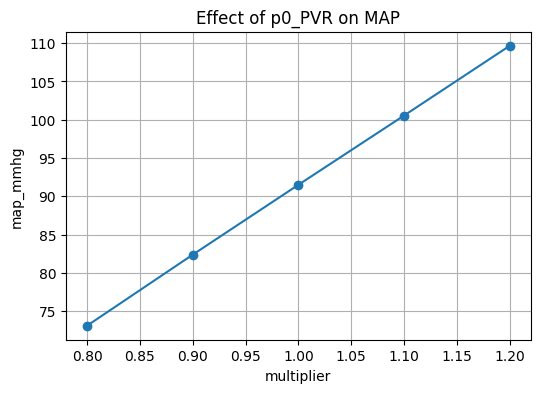

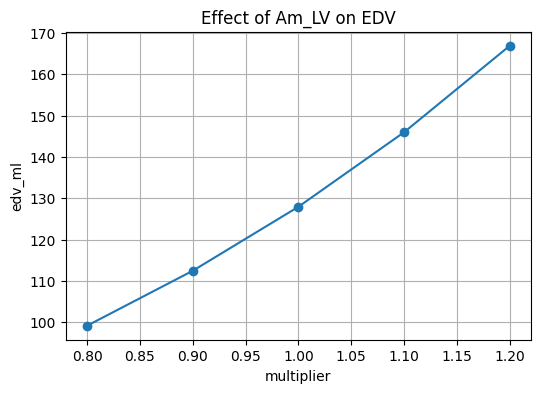

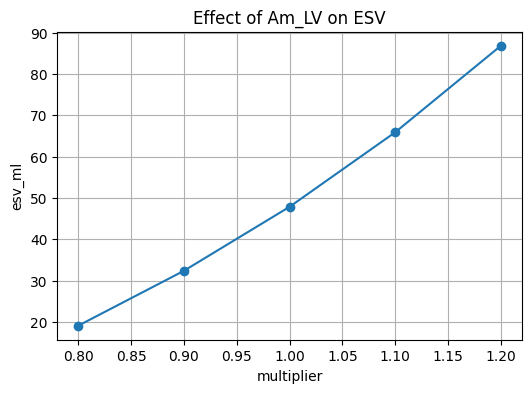

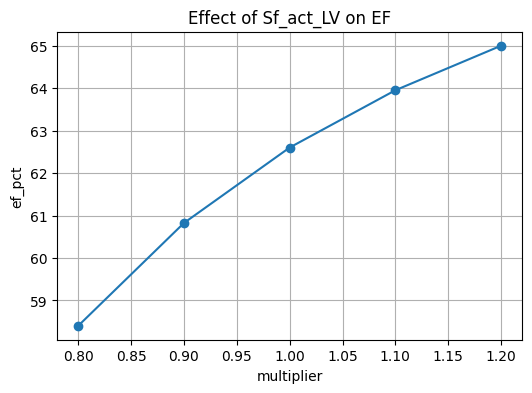

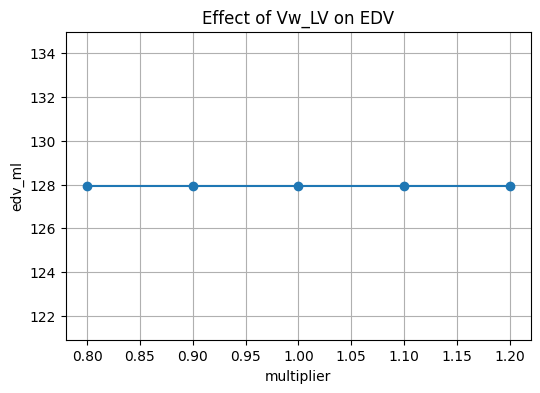

In [44]:
def plot_one_param_effect(df, x_col, y_col, title):
    plt.figure(figsize=(6,4))
    plt.plot(df[x_col], df[y_col], marker="o")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_one_param_effect(sweep_p0, "multiplier", "map_mmhg", "Effect of p0_PVR on MAP")
plot_one_param_effect(sweep_am, "multiplier", "edv_ml", "Effect of Am_LV on EDV")
plot_one_param_effect(sweep_am, "multiplier", "esv_ml", "Effect of Am_LV on ESV")
plot_one_param_effect(sweep_sf_act, "multiplier", "ef_pct", "Effect of Sf_act_LV on EF")
plot_one_param_effect(sweep_vw, "multiplier", "edv_ml", "Effect of Vw_LV on EDV")

In [45]:
def fit_p0_to_map(row, max_iter=10):
    target_map = row["map_mmhg"]

    m = create_base_model()
    theta = get_theta(m)

    for i in range(max_iter):
        m = set_theta(m, theta)
        m = set_pinned_inputs(m, co_l_min=row["co_l_min"])
        m = run_model_to_steady_state(m, verbose=False)

        sim = extract_outputs(m)
        err = sim["map_mmhg"] - target_map

        # simple proportional correction
        theta["p0_PVR"] *= (target_map / sim["map_mmhg"])

    return theta

In [46]:
theta_after_p0 = fit_p0_to_map(first_rest_row)
theta_after_p0

{'Am_LV': 0.00966859,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 120000.0,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [47]:
def fit_am_to_edv(row, theta, max_iter=10):
    target_edv = row["edv_ml"]

    for i in range(max_iter):
        sim, _ = simulate_with_theta(row, theta)

        ratio = target_edv / sim["edv_ml"]
        theta["Am_LV"] *= ratio

    return theta

In [48]:
theta_after_am = fit_am_to_edv(first_rest_row, theta_after_p0.copy())
theta_after_am

{'Am_LV': 0.011637963006745859,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 120000.0,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [49]:
def fit_sf_act_to_ef(row, theta, max_iter=10):
    target_ef = row["ef_pct"]

    for i in range(max_iter):
        sim, _ = simulate_with_theta(row, theta)

        ratio = target_ef / sim["ef_pct"]
        theta["Sf_act_LV"] *= ratio

    return theta

In [50]:
theta_final = fit_sf_act_to_ef(first_rest_row, theta_after_am.copy())
theta_final

{'Am_LV': 0.011637963006745859,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 186399.64028257105,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [51]:
final_sim, _ = simulate_with_theta(first_rest_row, theta_final)

comparison_df_final = compare_obs_vs_sim(obs_targets, final_sim)
display(comparison_df_final)

,metric,observed,simulated,abs_error,rel_error_pct
0,map_mmhg,99.666670,99.569449,-0.097221,-0.097546
1,co_l_min,5.653333,5.661106,0.007773,0.137485
2,ef_pct,53.000000,52.591219,-0.408781,-0.771285
3,edv_ml,175.333333,152.190318,-23.143016,-13.199439
4,esv_ml,89.666667,72.151575,-17.515092,-19.533560
5,pcwp_mmhg,NaN,6.965666,NaN,NaN


## Step 12: Refine residual volume mismatch

After the first calibration pass:
- MAP is nearly matched
- EF is nearly matched
- EDV and ESV are still low

We now test whether additional geometry refinement using `Vw_LV`
helps reduce the remaining volume mismatch.

In [52]:
# Start from the already calibrated theta_final
theta_stage2 = theta_final.copy()
theta_stage2

{'Am_LV': 0.011637963006745859,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 186399.64028257105,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [53]:
def volume_loss(obs, sim):
    """
    Focused loss on EDV and ESV only.
    """
    loss = 0.0

    if pd.notna(obs["edv_ml"]) and pd.notna(sim["edv_ml"]):
        loss += (sim["edv_ml"] - obs["edv_ml"]) ** 2

    if pd.notna(obs["esv_ml"]) and pd.notna(sim["esv_ml"]):
        loss += (sim["esv_ml"] - obs["esv_ml"]) ** 2

    return loss

In [54]:
# Sweep Vw_LV again, but now around the calibrated theta
vw_multipliers = [0.7, 0.85, 1.0, 1.15, 1.3]

records_vw_refined = []

for mult in vw_multipliers:
    theta_test = theta_stage2.copy()
    theta_test["Vw_LV"] = theta_stage2["Vw_LV"] * mult

    sim, _ = simulate_with_theta(first_rest_row, theta_test)
    vol_loss = volume_loss(obs_targets, sim)

    records_vw_refined.append({
        "multiplier": mult,
        "Vw_LV": theta_test["Vw_LV"],
        "edv_ml": sim["edv_ml"],
        "esv_ml": sim["esv_ml"],
        "ef_pct": sim["ef_pct"],
        "map_mmhg": sim["map_mmhg"],
        "volume_loss": vol_loss,
    })

vw_refined_df = pd.DataFrame(records_vw_refined)
display(vw_refined_df)

,multiplier,Vw_LV,edv_ml,esv_ml,ef_pct,map_mmhg,volume_loss
0,0.70,0.000052,152.190318,72.151575,52.591219,99.569449,842.377618
1,0.85,0.000063,152.190318,72.151575,52.591219,99.569449,842.377618
2,1.00,0.000074,152.190318,72.151575,52.591219,99.569449,842.377618
3,1.15,0.000085,152.190318,72.151575,52.591219,99.569449,842.377618
4,1.30,0.000096,152.190318,72.151575,52.591219,99.569449,842.377618


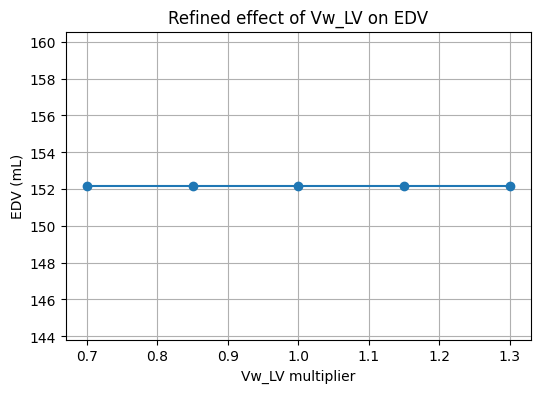

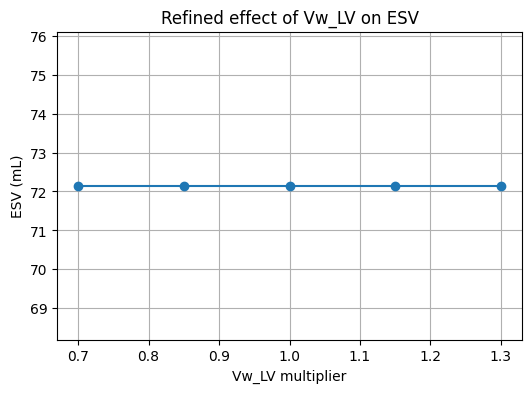

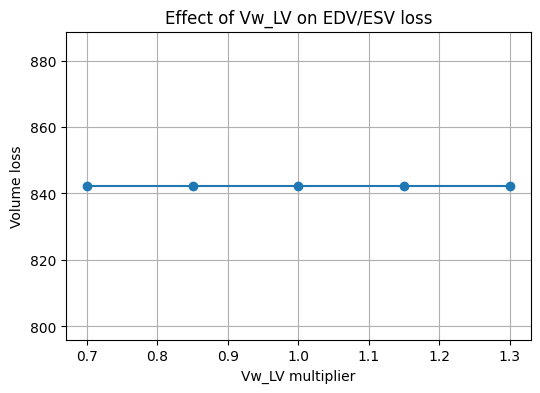

In [55]:
plt.figure(figsize=(6,4))
plt.plot(vw_refined_df["multiplier"], vw_refined_df["edv_ml"], marker="o")
plt.xlabel("Vw_LV multiplier")
plt.ylabel("EDV (mL)")
plt.title("Refined effect of Vw_LV on EDV")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(vw_refined_df["multiplier"], vw_refined_df["esv_ml"], marker="o")
plt.xlabel("Vw_LV multiplier")
plt.ylabel("ESV (mL)")
plt.title("Refined effect of Vw_LV on ESV")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(vw_refined_df["multiplier"], vw_refined_df["volume_loss"], marker="o")
plt.xlabel("Vw_LV multiplier")
plt.ylabel("Volume loss")
plt.title("Effect of Vw_LV on EDV/ESV loss")
plt.grid(True)
plt.show()

In [56]:
# Also test a second refinement sweep on Am_LV around the calibrated theta
am_refined_multipliers = [0.9, 0.95, 1.0, 1.05, 1.1]

records_am_refined = []

for mult in am_refined_multipliers:
    theta_test = theta_stage2.copy()
    theta_test["Am_LV"] = theta_stage2["Am_LV"] * mult

    sim, _ = simulate_with_theta(first_rest_row, theta_test)
    vol_loss = volume_loss(obs_targets, sim)

    records_am_refined.append({
        "multiplier": mult,
        "Am_LV": theta_test["Am_LV"],
        "edv_ml": sim["edv_ml"],
        "esv_ml": sim["esv_ml"],
        "ef_pct": sim["ef_pct"],
        "map_mmhg": sim["map_mmhg"],
        "volume_loss": vol_loss,
    })

am_refined_df = pd.DataFrame(records_am_refined)
display(am_refined_df)

,multiplier,Am_LV,edv_ml,esv_ml,ef_pct,map_mmhg,volume_loss
0,0.90,0.010474,133.038810,52.982013,60.175521,99.599580,3134.590528
1,0.95,0.011056,142.271444,62.222176,56.265169,99.587643,1846.288599
2,1.00,0.011638,152.190318,72.151575,52.591219,99.569449,842.377618
3,1.05,0.012220,162.831867,82.805838,49.146417,99.544034,203.357640
4,1.10,0.012802,174.220214,94.205861,45.927135,99.513675,21.843320


In [57]:
def refine_am_and_sf_act(row, theta, max_iter=10, alpha=2.0):
    """
    Joint refinement with stronger EF correction.

    alpha controls aggressiveness of Sf_act update.
    """
    target_edv = row["edv_ml"]
    target_ef = row["ef_pct"]

    theta = theta.copy()

    for i in range(max_iter):
        # --- Step 1: fix EDV ---
        sim, _ = simulate_with_theta(row, theta)

        if sim["edv_ml"] > 0:
            theta["Am_LV"] *= (target_edv / sim["edv_ml"])

        # --- Step 2: fix EF ---
        sim, _ = simulate_with_theta(row, theta)

        if sim["ef_pct"] > 0:
            ratio = target_ef / sim["ef_pct"]
            theta["Sf_act_LV"] *= (ratio ** alpha)

    return theta

In [58]:
theta_refined = refine_am_and_sf_act(first_rest_row, theta_after_p0.copy())
theta_refined

{'Am_LV': 0.014915423080761244,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 3678038.959344363,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [59]:
sim_refined, _ = simulate_with_theta(first_rest_row, theta_refined)

comparison_refined = compare_obs_vs_sim(obs_targets, sim_refined)
display(comparison_refined)

,metric,observed,simulated,abs_error,rel_error_pct
0,map_mmhg,99.666670,99.649591,-0.017079,-0.017136
1,co_l_min,5.653333,5.660045,0.006711,0.118712
2,ef_pct,53.000000,45.858835,-7.141165,-13.473897
3,edv_ml,175.333333,174.682582,-0.650751,-0.371151
4,esv_ml,89.666667,94.575186,4.908519,5.474185
5,pcwp_mmhg,NaN,14.982860,NaN,NaN


In [60]:
theta_refined_v2 = refine_am_and_sf_act(
    first_rest_row,
    theta_after_p0.copy(),
    max_iter=10,
    alpha=2.0
)
theta_refined_v2

{'Am_LV': 0.014915423080761244,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 3678038.959344363,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [61]:
sim_refined_v2, _ = simulate_with_theta(first_rest_row, theta_refined_v2)

comparison_refined_v2 = compare_obs_vs_sim(obs_targets, sim_refined_v2)
display(comparison_refined_v2)

,metric,observed,simulated,abs_error,rel_error_pct
0,map_mmhg,99.666670,99.649591,-0.017079,-0.017136
1,co_l_min,5.653333,5.660045,0.006711,0.118712
2,ef_pct,53.000000,45.858835,-7.141165,-13.473897
3,edv_ml,175.333333,174.682582,-0.650751,-0.371151
4,esv_ml,89.666667,94.575186,4.908519,5.474185
5,pcwp_mmhg,NaN,14.982860,NaN,NaN


In [62]:
# Freeze the good parameters from the latest calibration
theta_stage3 = theta_refined_v2.copy()
theta_stage3

{'Am_LV': 0.014915423080761244,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 3678038.959344363,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [63]:
def sf_act_sweep_around_theta(row, theta_base, multipliers):
    records = []

    for mult in multipliers:
        theta_test = theta_base.copy()
        theta_test["Sf_act_LV"] = theta_base["Sf_act_LV"] * mult

        sim, _ = simulate_with_theta(row, theta_test)

        esv_err = sim["esv_ml"] - row["esv_ml"]
        ef_err = sim["ef_pct"] - row["ef_pct"]

        records.append({
            "multiplier": mult,
            "Sf_act_LV": theta_test["Sf_act_LV"],
            "map_mmhg": sim["map_mmhg"],
            "edv_ml": sim["edv_ml"],
            "esv_ml": sim["esv_ml"],
            "ef_pct": sim["ef_pct"],
            "pcwp_mmhg": sim["pcwp_mmhg"],
            "esv_abs_error": esv_err,
            "ef_abs_error": ef_err,
            "esv_loss": esv_err**2,
            "ef_loss": ef_err**2,
            "combined_loss": esv_err**2 + 0.5 * ef_err**2
        })

    return pd.DataFrame(records)

sfact_multipliers = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
sfact_df = sf_act_sweep_around_theta(first_rest_row, theta_stage3, sfact_multipliers)
display(sfact_df)

,multiplier,Sf_act_LV,map_mmhg,edv_ml,esv_ml,ef_pct,pcwp_mmhg,esv_abs_error,ef_abs_error,esv_loss,ef_loss,combined_loss
0,0.7,2.574627e+06,99.626270,175.488113,95.412861,45.630015,12.618939,5.746194,-7.369985,33.018745,54.316678,60.177084
1,0.8,2.942431e+06,99.635587,175.199244,95.113628,45.711165,13.464559,5.446961,-7.288835,29.669383,53.127109,56.232937
2,0.9,3.310235e+06,99.643264,174.931462,94.835381,45.787121,14.248295,5.168714,-7.212879,26.715607,52.025616,52.728415
3,1.0,3.678039e+06,99.649591,174.682582,94.575186,45.858835,14.982860,4.908519,-7.141165,24.093561,50.996244,49.591683
4,1.1,4.045843e+06,99.654362,174.448596,94.330266,45.926612,15.674712,4.663599,-7.073388,21.749158,50.032815,46.765565
5,1.2,4.413647e+06,99.657320,174.227163,94.098384,45.990980,16.328943,4.431717,-7.009020,19.640118,49.126367,44.203301
6,1.3,4.781451e+06,99.658428,174.016565,93.878121,46.052193,16.949248,4.211454,-6.947807,17.736348,48.272026,41.872361


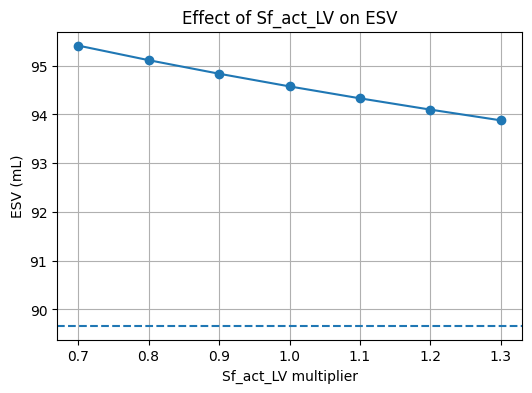

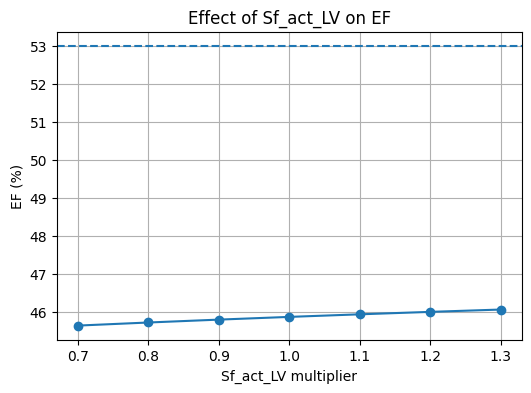

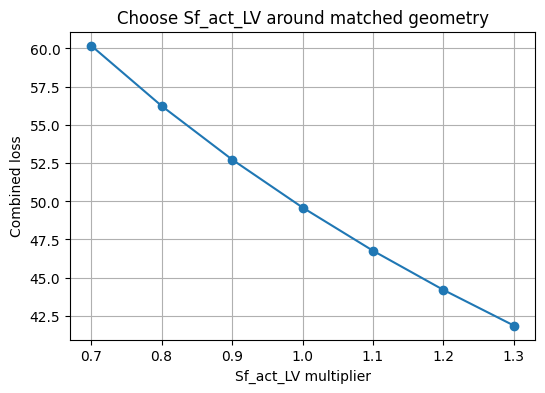

In [64]:
plt.figure(figsize=(6,4))
plt.plot(sfact_df["multiplier"], sfact_df["esv_ml"], marker="o")
plt.axhline(first_rest_row["esv_ml"], linestyle="--")
plt.xlabel("Sf_act_LV multiplier")
plt.ylabel("ESV (mL)")
plt.title("Effect of Sf_act_LV on ESV")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sfact_df["multiplier"], sfact_df["ef_pct"], marker="o")
plt.axhline(first_rest_row["ef_pct"], linestyle="--")
plt.xlabel("Sf_act_LV multiplier")
plt.ylabel("EF (%)")
plt.title("Effect of Sf_act_LV on EF")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sfact_df["multiplier"], sfact_df["combined_loss"], marker="o")
plt.xlabel("Sf_act_LV multiplier")
plt.ylabel("Combined loss")
plt.title("Choose Sf_act_LV around matched geometry")
plt.grid(True)
plt.show()

In [65]:
best_idx = sfact_df["combined_loss"].idxmin()
best_sfact_row = sfact_df.loc[best_idx]
best_sfact_row

multiplier       1.300000e+00
Sf_act_LV        4.781451e+06
map_mmhg         9.965843e+01
edv_ml           1.740166e+02
esv_ml           9.387812e+01
ef_pct           4.605219e+01
pcwp_mmhg        1.694925e+01
esv_abs_error    4.211454e+00
ef_abs_error    -6.947807e+00
esv_loss         1.773635e+01
ef_loss          4.827203e+01
combined_loss    4.187236e+01
Name: 6, dtype: float64

In [66]:
theta_stage4 = theta_stage3.copy()
theta_stage4["Sf_act_LV"] = float(best_sfact_row["Sf_act_LV"])

sim_stage4, _ = simulate_with_theta(first_rest_row, theta_stage4)
comparison_stage4 = compare_obs_vs_sim(obs_targets, sim_stage4)
display(comparison_stage4)

,metric,observed,simulated,abs_error,rel_error_pct
0,map_mmhg,99.666670,99.658428,-0.008242,-0.008269
1,co_l_min,5.653333,5.661110,0.007777,0.137557
2,ef_pct,53.000000,46.052193,-6.947807,-13.109070
3,edv_ml,175.333333,174.016565,-1.316768,-0.751009
4,esv_ml,89.666667,93.878121,4.211454,4.696789
5,pcwp_mmhg,NaN,16.949248,NaN,NaN


In [67]:
# Reset to a physically reasonable intermediate theta:
# keep p0_PVR from successful MAP fit
# keep Am_LV from successful volume fit
# restore Sf_act_LV and Vw_LV to baseline defaults

theta_baseline = get_theta(create_base_model())

theta_reset = theta_after_p0.copy()
theta_reset["Am_LV"] = theta_refined_v2["Am_LV"]   # keep volume geometry
theta_reset["Sf_act_LV"] = theta_baseline["Sf_act_LV"]  # reset contractility
theta_reset["Vw_LV"] = theta_baseline["Vw_LV"]          # reset wall volume

theta_reset

{'Am_LV': 0.014915423080761244,
 'Sf_pas_LV': 731.24545453,
 'Sf_act_LV': 120000.0,
 'Vw_LV': 7.35720515e-05,
 'p0_PVR': 13290.974531276408}

In [68]:
# First, probe candidate timing / HR paths in the model

hr_candidates = [
    "Model.t_cycle",
    "Model.Timings.t_cycle",
    "Model.timings.t_cycle",
    "Model.Peri.t_cycle",
    "Model.hr",
    "Model.HR",
    "Model.Peri.HR",
]

for p in hr_candidates:
    try:
        val = test_model.get(p)
        print(f"{p}: SUCCESS -> {val}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.t_cycle: SUCCESS -> 0.85
Model.Timings.t_cycle: FAILED -> ValueError('Parameter "Model.Timings.parameter_type:t_cycle" not found. ')
Model.timings.t_cycle: FAILED -> ValueError('Parameter "Model.timings.parameter_type:t_cycle" not found. ')
Model.Peri.t_cycle: FAILED -> ValueError('Parameter "Model.Peri.parameter_type:t_cycle" not found. ')
Model.hr: FAILED -> ValueError('Parameter "Model.parameter_type:hr" not found. ')
Model.HR: FAILED -> ValueError('Parameter "Model.parameter_type:HR" not found. ')
Model.Peri.HR: FAILED -> ValueError('Parameter "Model.Peri.parameter_type:HR" not found. ')


In [69]:
# Also inspect timing-related names from the model object itself

timing_related = [name for name in dir(test_model) if "time" in name.lower() or "cycle" in name.lower() or "hr" in name.lower()]
timing_related

[]

In [70]:
# Probe likely settable timing parameters using what worked before:
# sometimes the model exposes cycle time rather than HR directly

timing_probe_paths = [
    "Model.Peri.t_cycle",
    "Model.Peri.hr",
    "Model.Timings.t_cycle",
    "Model.Timings.hr",
    "Model.t_cycle",
]

for p in timing_probe_paths:
    try:
        val = test_model.get(p)
        print(f"{p}: SUCCESS -> {val}")
    except Exception as e:
        print(f"{p}: FAILED -> {repr(e)}")

Model.Peri.t_cycle: FAILED -> ValueError('Parameter "Model.Peri.parameter_type:t_cycle" not found. ')
Model.Peri.hr: FAILED -> ValueError('Parameter "Model.Peri.parameter_type:hr" not found. ')
Model.Timings.t_cycle: FAILED -> ValueError('Parameter "Model.Timings.parameter_type:t_cycle" not found. ')
Model.Timings.hr: FAILED -> ValueError('Parameter "Model.Timings.parameter_type:hr" not found. ')
Model.t_cycle: SUCCESS -> 0.85


In [71]:
# Re-evaluate the reset theta before HR pinning
sim_reset, _ = simulate_with_theta(first_rest_row, theta_reset)
comparison_reset = compare_obs_vs_sim(obs_targets, sim_reset)
display(comparison_reset)

,metric,observed,simulated,abs_error,rel_error_pct
0,map_mmhg,99.666670,99.767814,0.101144,0.101482
1,co_l_min,5.653333,5.646230,-0.007103,-0.125643
2,ef_pct,53.000000,28.155707,-24.844293,-46.876025
3,edv_ml,175.333333,285.421860,110.088526,62.788133
4,esv_ml,89.666667,205.059318,115.392651,128.690689
5,pcwp_mmhg,NaN,20.603994,NaN,NaN


In [72]:
# ── HR PINNING PROBE ──────────────────────────────────────────────────────────
# Run this once to find the correct t_cycle path on your install.
# We will use the result to fix set_pinned_inputs below.

probe_model = create_base_model()
probe_model = run_model_to_steady_state(probe_model, n_beats=20, verbose=False)

hr_probe_paths = [
    "Model.t_cycle",
    "Model.Peri.t_cycle",
    "Model.Timings.t_cycle",
    "Model.Peri.SyArt.t_cycle",
    "Model.Peri.TriSeg.t_cycle",
    "Model.PFC.t_cycle",
]

print("=== HR / t_cycle probe ===")
working_tcycle_path = None
for p in hr_probe_paths:
    try:
        val = probe_model.get(p)
        bpm = 60.0 / float(val)
        print(f"  SUCCESS  {p}  ->  t_cycle={val:.4f} s  ({bpm:.1f} bpm)")
        if working_tcycle_path is None:
            working_tcycle_path = p
    except Exception as e:
        print(f"  FAILED   {p}  ->  {e}")

print()
if working_tcycle_path:
    print(f"Will use: '{working_tcycle_path}'")
    # Verify we can also SET it
    test_hr = 75.0
    test_tcycle = 60.0 / test_hr
    try:
        probe_model.set(working_tcycle_path, test_tcycle)
        readback = probe_model.get(working_tcycle_path)
        print(f"SET test: wrote {test_tcycle:.4f} s, read back {readback:.4f} s  -> OK")
    except Exception as e:
        print(f"SET test FAILED: {e}")
        working_tcycle_path = None
else:
    print("No t_cycle path found. HR pinning will be skipped.")

=== HR / t_cycle probe ===
  SUCCESS  Model.t_cycle  ->  t_cycle=0.8500 s  (70.6 bpm)
  FAILED   Model.Peri.t_cycle  ->  Parameter "Model.Peri.parameter_type:t_cycle" not found. 
  FAILED   Model.Timings.t_cycle  ->  Parameter "Model.Timings.parameter_type:t_cycle" not found. 
  FAILED   Model.Peri.SyArt.t_cycle  ->  Parameter "Model.Peri.SyArt.parameter_type:t_cycle" not found. 
  FAILED   Model.Peri.TriSeg.t_cycle  ->  Parameter "Model.Peri.TriSeg.parameter_type:t_cycle" not found. 
  FAILED   Model.PFC.t_cycle  ->  Parameter "Model.PFC.parameter_type:t_cycle" not found. 

Will use: 'Model.t_cycle'
SET test: wrote 0.8000 s, read back 0.8000 s  -> OK


In [73]:
# ── FIXED set_pinned_inputs ───────────────────────────────────────────────────
# Replace the old set_pinned_inputs with this one.
# Paste the working path from Cell 1 into TCYCLE_PATH.
# If none worked, leave it as None and HR will be skipped (CO-only pinning).

TCYCLE_PATH = working_tcycle_path   # or hard-code e.g. "Model.t_cycle"

def set_pinned_inputs(model, hr_bpm=None, co_l_min=None):
    """
    Pin measured patient inputs to the model before running.
      - CO  via Model.PFC.q0  (confirmed working)
      - HR  via t_cycle       (path found by probe above)
    """
    if co_l_min is not None and not pd.isna(co_l_min):
        model.set("Model.PFC.q0", float(co_l_min) * LPM_TO_M3PS)

    if hr_bpm is not None and not pd.isna(hr_bpm) and TCYCLE_PATH is not None:
        t_cycle = 60.0 / float(hr_bpm)
        model.set(TCYCLE_PATH, t_cycle)

    return model

# ── Quick verification ────────────────────────────────────────────────────────
verify_model = create_base_model()
verify_model = set_pinned_inputs(verify_model, hr_bpm=72.0, co_l_min=5.5)
verify_model = run_model_to_steady_state(verify_model, n_beats=20, verbose=False)
out_verify = extract_outputs(verify_model)

print("Pinned HR=72 bpm, CO=5.5 L/min")
print(f"  Simulated MAP  : {out_verify['map_mmhg']:.1f} mmHg")
print(f"  Simulated CO   : {out_verify['co_l_min']:.2f} L/min")
print(f"  Simulated EDV  : {out_verify['edv_ml']:.1f} mL")
print(f"  Simulated EF   : {out_verify['ef_pct']:.1f} %")
print(f"  Simulated PCWP : {out_verify['pcwp_mmhg']:.1f} mmHg")

Pinned HR=72 bpm, CO=5.5 L/min
  Simulated MAP  : 91.5 mmHg
  Simulated CO   : 5.51 L/min
  Simulated EDV  : 124.3 mL
  Simulated EF   : 61.4 %
  Simulated PCWP : 7.8 mmHg


In [82]:
# ── THETA BOUNDS AND clip_theta ───────────────────────────────────────────────
THETA_BOUNDS = {
    "Am_LV"     : (0.002,  0.030),    # m²
    "Sf_pas_LV" : (200,    8000),     # Pa
    "Sf_act_LV" : (5000,   400000),   # Pa
    "Vw_LV"     : (0.00005, 0.0006),  # m³
    "p0_PVR"    : (3000,   40000),    # Pa
}

def clip_theta(theta):
    clipped = theta.copy()
    for k, (lo, hi) in THETA_BOUNDS.items():
        if k in clipped:
            clipped[k] = float(np.clip(clipped[k], lo, hi))
    return clipped

# Also inputs_are_valid in case it's missing too
INPUT_BOUNDS = {
    "hr_bpm"   : (30,  200),
    "co_l_min" : (1.0, 12.0),
    "map_mmhg" : (40,  180),
}

def inputs_are_valid(row):
    for col, (lo, hi) in INPUT_BOUNDS.items():
        val = row.get(col)
        if pd.isna(val):
            return False, f"{col} is NaN"
        if not (lo <= float(val) <= hi):
            return False, f"{col}={val:.2f} outside [{lo}, {hi}]"
    return True, None

In [83]:
# ── CONSOLIDATED fit_patient() ────────────────────────────────────────────────

# ── FASTER simulate_row: fewer beats during fitting, full run only at end ─────

from circadapt.error import ModelCrashed, ModelNotStable

def run_model_safe(model, n_beats=10):
    """
    Run model, return (model, ok, error_string).
    Never raises — all exceptions are caught and returned as status.
    Uses the correct CircAdapt API: model.run(n_beats).
    """
    try:
        model.run(n_beats)
        return model, True, None
    except ModelCrashed:
        return model, False, "ModelCrashed"
    except ModelNotStable:
        return model, False, "ModelNotStable"
    except Exception as e:
        return model, False, f"{type(e).__name__}: {e}"

def simulate_row(row, theta, n_beats=10):
    m = create_base_model()
    m = set_theta(m, theta)
    m = set_pinned_inputs(m,
                          hr_bpm=row.get("hr_bpm"),
                          co_l_min=row.get("co_l_min"))
    m, ok, err = run_model_safe(m, n_beats=n_beats)
    if not ok:
        return None, False, err

    try:
        v_lv    = m['Cavity']['V'][:, 'cLv']     # LV volume
        p_syart = m['Cavity']['p'][:, 'SyArt']   # systemic arterial pressure
        p_la    = m['Cavity']['p'][:, 'La']       # LA pressure → PCWP proxy
        q_sy    = m['ArtVen']['q'][:, 'CiSy']    # systemic flow → CO

        edv_ml = float(np.max(v_lv)  * 1e6)
        esv_ml = float(np.min(v_lv)  * 1e6)
        ef_pct = float((edv_ml - esv_ml) / edv_ml * 100.0) if edv_ml > 0 else np.nan

        outputs = {
            "map_mmhg" : float(np.mean(p_syart) / MMHG_TO_PA),
            "sbp_mmhg" : float(np.max(p_syart)  / MMHG_TO_PA),
            "dbp_mmhg" : float(np.min(p_syart)  / MMHG_TO_PA),
            "co_l_min" : float(np.mean(np.abs(q_sy)) * 60000.0),
            "edv_ml"   : edv_ml,
            "esv_ml"   : esv_ml,
            "ef_pct"   : ef_pct,
            "pcwp_mmhg": float(np.mean(p_la) / MMHG_TO_PA),
        }
        return outputs, True, None

    except Exception as e:
        return None, False, f"extract_failed: {type(e).__name__}: {e}"

def simulate_row_final(row, theta):
    return simulate_row(row, theta, n_beats=20)

def fit_patient(row, n_outer=4, n_inner=8, verbose=False):
    """
    Fit 5 Morris parameters to one resting row.
    Works with the new simulate_row which returns (outputs, ok, err).
    """
    obs = {
        "map_mmhg" : row.get("map_mmhg"),
        "edv_ml"   : row.get("edv_ml"),
        "esv_ml"   : row.get("esv_ml"),
        "ef_pct"   : row.get("ef_pct"),
        "pcwp_mmhg": row.get("pcwp_mmhg"),
        "co_l_min" : row.get("co_l_min"),
    }

    theta = get_theta(create_base_model())

    has_map  = pd.notna(obs["map_mmhg"])   and float(obs["map_mmhg"])  > 0
    has_edv  = pd.notna(obs["edv_ml"])     and float(obs["edv_ml"])    > 0
    has_esv  = pd.notna(obs["esv_ml"])     and float(obs["esv_ml"])    > 0
    has_ef   = pd.notna(obs["ef_pct"])     and float(obs["ef_pct"])    > 0
    has_pcwp = pd.notna(obs["pcwp_mmhg"])  and float(obs["pcwp_mmhg"]) >= 0

    def safe_sim(theta):
        """Run simulate_row, return outputs dict or None on failure."""
        s, ok, err = simulate_row(row, theta)
        return s if ok else None

    # Pass A: p0_PVR → MAP
    if has_map:
        for _ in range(n_inner):
            s = safe_sim(theta)
            if s is None: break
            if s["map_mmhg"] > 0:
                theta["p0_PVR"] *= float(obs["map_mmhg"]) / s["map_mmhg"]
            theta = clip_theta(theta)

    # Outer loop: Am_LV / Sf_act_LV / Vw_LV
    loss_history = []
    for outer in range(n_outer):

        if has_edv:
            for _ in range(n_inner):
                s = safe_sim(theta)
                if s is None: break
                if s["edv_ml"] > 0:
                    theta["Am_LV"] *= (float(obs["edv_ml"]) / s["edv_ml"]) ** 0.5
                theta = clip_theta(theta)

        if has_ef:
            for _ in range(n_inner):
                s = safe_sim(theta)
                if s is None: break
                if s["ef_pct"] > 0:
                    theta["Sf_act_LV"] *= (float(obs["ef_pct"]) / s["ef_pct"]) ** 0.5
                theta = clip_theta(theta)

        if has_esv and has_edv:
            for _ in range(n_inner):
                s = safe_sim(theta)
                if s is None: break
                if s["esv_ml"] > 0:
                    theta["Vw_LV"] *= (float(obs["esv_ml"]) / s["esv_ml"]) ** 0.3
                theta = clip_theta(theta)

        # track loss
        s = safe_sim(theta)
        if s:
            loss = 0.0
            if has_map: loss += ((s["map_mmhg"] - float(obs["map_mmhg"])) / max(float(obs["map_mmhg"]), 1)) ** 2
            if has_edv: loss += ((s["edv_ml"]   - float(obs["edv_ml"]))   / max(float(obs["edv_ml"]),   1)) ** 2
            if has_esv: loss += ((s["esv_ml"]   - float(obs["esv_ml"]))   / max(float(obs["esv_ml"]),   1)) ** 2
            if has_ef:  loss += ((s["ef_pct"]   - float(obs["ef_pct"]))   / max(float(obs["ef_pct"]),   1)) ** 2
            loss_history.append(loss)
            if verbose:
                print(f"  outer {outer+1}/{n_outer}  loss={loss:.4f}"
                      f"  MAP={s['map_mmhg']:.1f}  EDV={s['edv_ml']:.1f}"
                      f"  ESV={s['esv_ml']:.1f}  EF={s['ef_pct']:.1f}")

    # Pass E: Sf_pas_LV → PCWP
    if has_pcwp and float(obs["pcwp_mmhg"]) > 2:
        for _ in range(n_inner):
            s = safe_sim(theta)
            if s is None: break
            if s["pcwp_mmhg"] > 0:
                theta["Sf_pas_LV"] *= (float(obs["pcwp_mmhg"]) / s["pcwp_mmhg"]) ** 0.4
            theta = clip_theta(theta)

    # Final simulation
    sim_final, ok, _ = simulate_row_final(row, theta)

    if sim_final is None:
        return theta, {}, False, loss_history

    errors = []
    if has_map: errors.append(abs(sim_final["map_mmhg"] - float(obs["map_mmhg"])) / max(float(obs["map_mmhg"]), 1))
    if has_edv: errors.append(abs(sim_final["edv_ml"]   - float(obs["edv_ml"]))   / max(float(obs["edv_ml"]),   1))
    if has_ef:  errors.append(abs(sim_final["ef_pct"]   - float(obs["ef_pct"]))   / max(float(obs["ef_pct"]),   1))
    converged = all(e < 0.05 for e in errors) if errors else False

    return theta, sim_final, converged, loss_history


# ── Smoke test on the first rest row ──────────────────────────────────────────
# Smoke test
print("Running fit_patient() on first rest row...")
theta_test, sim_test, conv_test, lh_test = fit_patient(
    rest_df.iloc[0], n_outer=4, n_inner=8, verbose=True
)

print(f"\nConverged: {conv_test}")
if sim_test:
    print(f"\n{'Metric':<14} {'Observed':>10} {'Simulated':>10} {'Abs Error':>12}")
    print("-" * 50)
    obs_test = {k: rest_df.iloc[0][k] for k in
                ["map_mmhg","co_l_min","edv_ml","esv_ml","ef_pct","pcwp_mmhg"]}
    for k in ["map_mmhg","co_l_min","edv_ml","esv_ml","ef_pct","pcwp_mmhg"]:
        o = obs_test.get(k, float("nan"))
        s = sim_test.get(k, float("nan"))
        err = s - o if pd.notna(o) and pd.notna(s) else float("nan")
        print(f"  {k:<12} {o:>10.2f} {s:>10.2f} {err:>12.2f}")
else:
    print("Simulation failed — check simulate_row output above")

Running fit_patient() on first rest row...
  outer 1/4  loss=0.0094  MAP=100.0  EDV=171.8  ESV=81.2  EF=52.7
  outer 2/4  loss=0.0090  MAP=100.2  EDV=172.1  ESV=81.4  EF=52.7
  outer 3/4  loss=0.0086  MAP=100.3  EDV=172.3  ESV=81.5  EF=52.7
  outer 4/4  loss=0.0083  MAP=100.4  EDV=172.6  ESV=81.7  EF=52.7

Converged: True

Metric           Observed  Simulated    Abs Error
--------------------------------------------------
  map_mmhg          99.67      98.31        -1.36
  co_l_min           5.65       5.64        -0.01
  edv_ml           175.33     170.15        -5.18
  esv_ml            89.67      80.48        -9.19
  ef_pct            53.00      52.70        -0.30
  pcwp_mmhg           nan       8.98          nan


In [84]:
# DIAGNOSTIC — run this now
row0 = rest_df.iloc[0]
theta0 = get_theta(create_base_model())

print("=== Test 1: bare run_model_safe ===")
m = create_base_model()
m, ok, err = run_model_safe(m, n_beats=5)
print(f"ok={ok}  err={err}")

print("\n=== Test 2: simulate_row with default theta ===")
s, ok, err = simulate_row(row0, theta0, n_beats=5)
print(f"ok={ok}  err={err}")
print(f"outputs={s}")

print("\n=== Test 3: dict-style path probe ===")
m2 = create_base_model()
m2.run(5)

for label, expr in [
    ("LV volume",    "m2['Cavity']['V'][:, 'cLv']"),
    ("SyArt press",  "m2['Cavity']['p'][:, 'cSyArt']"),
    ("LA press",     "m2['Cavity']['p'][:, 'cLa']"),
    ("SyVen flow",   "m2['ArtVen']['q'][:, 'SyVen']"),
]:
    try:
        val = eval(expr)
        print(f"  OK  {label}: shape={val.shape}, mean={float(np.mean(val)):.4f}")
    except Exception as e:
        print(f"  FAIL {label}: {type(e).__name__}: {e}")

print("\n=== Test 4: what keys exist in Cavity and ArtVen? ===")
m3 = create_base_model()
m3.run(5)
try:
    print("Cavity objects:", m3['Cavity'].objects)
except: pass
try:
    print("ArtVen objects:", m3['ArtVen'].objects)
except: pass
try:
    print("Cavity signals:", m3['Cavity'].signals)
except: pass
try:
    print("ArtVen signals:", m3['ArtVen'].signals)
except: pass

=== Test 1: bare run_model_safe ===
ok=True  err=None

=== Test 2: simulate_row with default theta ===
ok=True  err=None
outputs={'map_mmhg': 92.05959688092784, 'sbp_mmhg': 124.06916922937232, 'dbp_mmhg': 66.89235004610802, 'co_l_min': 5.915047260004462, 'edv_ml': 136.18428693310506, 'esv_ml': 47.1205679580443, 'ef_pct': 65.39940912479108, 'pcwp_mmhg': 10.267106177792341}

=== Test 3: dict-style path probe ===
  OK  LV volume: shape=(426,), mean=0.0001
  FAIL SyArt press: ValueError: Object not found.
  FAIL LA press: ValueError: Object not found.
  FAIL SyVen flow: ValueError: Object not found.

=== Test 4: what keys exist in Cavity and ArtVen? ===
Cavity objects: ['Model.SyArt', 'Model.SyVen', 'Model.PuArt', 'Model.PuVen', 'Model.Peri', 'Model.Peri.La', 'Model.Peri.Ra', 'Model.Peri.TriSeg.cLv', 'Model.Peri.TriSeg.cRv']
ArtVen objects: ['Model.CiSy', 'Model.CiPu']
Cavity signals: ['A', 'p', 'p_trans', 'q', 'V', 'dV_dt']
ArtVen signals: ['q']


In [85]:
# STEP 1: confirm paths directly — run this cell alone
m = create_base_model()
m.run(5)

for label, expr in [
    ("LV volume",   "m['Cavity']['V'][:, 'Model.Peri.TriSeg.cLv']"),
    ("SyArt press", "m['Cavity']['p'][:, 'Model.SyArt']"),
    ("LA press",    "m['Cavity']['p'][:, 'Model.Peri.La']"),
    ("CiSy flow",   "m['ArtVen']['q'][:, 'Model.CiSy']"),
]:
    try:
        val = eval(expr)
        print(f"  OK   {label}: shape={val.shape}, mean={float(np.mean(val)):.6f}")
    except Exception as e:
        print(f"  FAIL {label}: {e}")

  FAIL LV volume: Object not found.
  FAIL SyArt press: Object not found.
  FAIL LA press: Object not found.
  FAIL CiSy flow: Object not found.


In [86]:
# STEP 2: brute-force probe — find exact working syntax
m = create_base_model()
m.run(5)

# Try short names (just last part after final dot)
print("=== Short names ===")
for label, expr in [
    ("LV volume short",   "m['Cavity']['V'][:, 'cLv']"),
    ("SyArt press short", "m['Cavity']['p'][:, 'SyArt']"),
    ("LA press short",    "m['Cavity']['p'][:, 'La']"),
    ("CiSy flow short",   "m['ArtVen']['q'][:, 'CiSy']"),
    ("SyVen short",       "m['Cavity']['p'][:, 'SyVen']"),
    ("Peri short",        "m['Cavity']['p'][:, 'Peri']"),
]:
    try:
        val = eval(expr)
        print(f"  OK   {label}: mean={float(np.mean(val)):.6f}")
    except Exception as e:
        print(f"  FAIL {label}: {e}")

# Try integer indices based on objects list order
print("\n=== Integer indices ===")
objects = m['Cavity'].objects
print("Objects:", objects)
for i, obj in enumerate(objects):
    try:
        val = m['Cavity']['p'][:, i]
        mean_mmhg = float(np.mean(val)) / MMHG_TO_PA
        print(f"  index {i} ({obj}): mean={mean_mmhg:.1f} mmHg")
    except Exception as e:
        print(f"  index {i} ({obj}): FAIL {e}")

print("\n=== ArtVen integer indices ===")
av_objects = m['ArtVen'].objects
print("ArtVen objects:", av_objects)
for i, obj in enumerate(av_objects):
    try:
        val = m['ArtVen']['q'][:, i]
        mean_lpm = float(np.mean(np.abs(val))) * 60000.0
        print(f"  index {i} ({obj}): mean={mean_lpm:.2f} L/min")
    except Exception as e:
        print(f"  index {i} ({obj}): FAIL {e}")

=== Short names ===
  OK   LV volume short: mean=0.000087
  OK   SyArt press short: mean=12196.844969
  OK   LA press short: mean=957.607299
  OK   CiSy flow short: mean=0.000085
  OK   SyVen short: mean=295.331220
  OK   Peri short: mean=21.160184

=== Integer indices ===
Objects: ['Model.SyArt', 'Model.SyVen', 'Model.PuArt', 'Model.PuVen', 'Model.Peri', 'Model.Peri.La', 'Model.Peri.Ra', 'Model.Peri.TriSeg.cLv', 'Model.Peri.TriSeg.cRv']
  index 0 (Model.SyArt): mean=91.5 mmHg
  index 1 (Model.SyVen): mean=2.2 mmHg
  index 2 (Model.PuArt): mean=17.2 mmHg
  index 3 (Model.PuVen): mean=7.4 mmHg
  index 4 (Model.Peri): mean=0.2 mmHg
  index 5 (Model.Peri.La): mean=7.2 mmHg
  index 6 (Model.Peri.Ra): mean=1.9 mmHg
  index 7 (Model.Peri.TriSeg.cLv): mean=41.5 mmHg
  index 8 (Model.Peri.TriSeg.cRv): mean=8.7 mmHg

=== ArtVen integer indices ===
ArtVen objects: ['Model.CiSy', 'Model.CiPu']
  index 0 (Model.CiSy): mean=5.10 L/min
  index 1 (Model.CiPu): mean=5.10 L/min


In [87]:
row0 = rest_df.iloc[0]
theta0 = get_theta(create_base_model())
s, ok, err = simulate_row(row0, theta0, n_beats=5)
print(f"ok={ok}  err={err}")
print(s)

ok=True  err=None
{'map_mmhg': 92.05959688092784, 'sbp_mmhg': 124.06916922937232, 'dbp_mmhg': 66.89235004610802, 'co_l_min': 5.915047260004462, 'edv_ml': 136.18428693310506, 'esv_ml': 47.1205679580443, 'ef_pct': 65.39940912479108, 'pcwp_mmhg': 10.267106177792341}


In [88]:
# ── DIAGNOSTIC: test fit_patient on first 3 rows individually ─────────────────

for i in range(3):
    row = rest_df.iloc[i]
    print(f"\n{'='*60}")
    print(f"Row {i} — patient: {row['patient_id']}")
    print(f"  HR={row['hr_bpm']}  CO={row['co_l_min']}  MAP={row['map_mmhg']}")
    print(f"  EDV={row['edv_ml']}  ESV={row['esv_ml']}  EF={row['ef_pct']}  PCWP={row['pcwp_mmhg']}")

    try:
        theta_fit, sim_fit, converged, loss_hist = fit_patient(
            row, n_outer=4, n_inner=8, verbose=True
        )
        print(f"  SUCCESS — converged={converged}")
        print(f"  sim: MAP={sim_fit['map_mmhg']:.1f}  EDV={sim_fit['edv_ml']:.1f}  EF={sim_fit['ef_pct']:.1f}")
        print(f"  theta: {theta_fit}")
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")

        # Now probe which pass crashes by running them manually
        print("\n  -- Probing which pass causes crash --")
        m0 = create_base_model()
        theta = get_theta(m0)
        print(f"  Default theta: {theta}")

        # Try just pinning + running with no parameter changes
        try:
            sim0 = simulate_row(row, theta)
            print(f"  Default sim OK: {sim0}")
        except Exception as e2:
            print(f"  Default sim FAILED: {e2}")
            print("  --> Problem is with pinned inputs (HR or CO value), not fitting")


Row 0 — patient: 17-1141, healthy control_1
  HR=63  CO=5.653333333333333  MAP=99.66667
  EDV=175.33333333333334  ESV=89.66666666666667  EF=53  PCWP=nan
  outer 1/4  loss=0.0094  MAP=100.0  EDV=171.8  ESV=81.2  EF=52.7
  outer 2/4  loss=0.0090  MAP=100.2  EDV=172.1  ESV=81.4  EF=52.7
  outer 3/4  loss=0.0086  MAP=100.3  EDV=172.3  ESV=81.5  EF=52.7
  outer 4/4  loss=0.0083  MAP=100.4  EDV=172.6  ESV=81.7  EF=52.7
  SUCCESS — converged=True
  sim: MAP=98.3  EDV=170.2  EF=52.7
  theta: {'Am_LV': 0.011751399871042121, 'Sf_pas_LV': 731.24545453, 'Sf_act_LV': 150052.65132350568, 'Vw_LV': 0.00018556401125637185, 'p0_PVR': 13107.627560830142}

Row 1 — patient: 17-1141, healthy control_1
  HR=63  CO=9.319999999999999  MAP=99.66666666666667
  EDV=126.85714285714286  ESV=47.714285714285715  EF=79.14285714285714  PCWP=nan
  outer 1/4  loss=0.6863  MAP=100.1  EDV=136.4  ESV=9.3  EF=93.2
  outer 2/4  loss=0.3493  MAP=101.4  EDV=135.2  ESV=19.9  EF=85.2
  outer 3/4  loss=0.2451  MAP=104.4  EDV=128.

In [89]:
# What conditions exist in the full dataset?
print(model_df["condition"].value_counts())
print("\nrest_df conditions:")
print(rest_df["condition"].value_counts())

# Test simulate_row on row 0 in isolation
row = rest_df.iloc[0]
print("\nTesting simulate_row directly...")
theta = get_theta(create_base_model())
try:
    sim = simulate_row(row, theta)
    print("OK:", sim)
except Exception as e:
    print(f"CRASH: {type(e).__name__}: {e}")
    print(f"Row inputs: HR={row['hr_bpm']}, CO={row['co_l_min']}, MAP={row['map_mmhg']}")

condition
supine rest                               34
upright rest                              34
mild                                      34
peak                                      34
moderate                                  32
noninvasive_normoxia_upright_rest         10
noninvasive_normoxia_peak_exercise        10
noninvasive_hypoxia_fio21                 10
noninvasive_hypoxia_fio17                 10
noninvasive_hypoxia_fio15                 10
noninvasive_hypoxia_fio12                 10
noninvasive_hypoxia_fio12_upright_rest    10
noninvasive_hypoxia_peak_exercise         10
invasive_normoxia_supine_rest             10
invasive_normoxia_upright_rest            10
invasive_upright_rest_fio12               10
invasive_hypoxia_stage_1_exercise         10
invasive_hypoxia_peak_exercise             9
invasive_rest_fio12                        9
invasive_rest_fio17                        9
invasive_rest_fio15                        9
invasive_normoxia_stage_1_exercise         9


In [90]:
# DIAGNOSTIC — run this before anything else
print("=== Condition breakdown ===")
print(model_df["condition"].value_counts())

print("\n=== rest_df conditions ===")
print(rest_df["condition"].value_counts())

print("\n=== Testing simulate_row on row 0 ===")
row = rest_df.iloc[0]
print(f"HR={row['hr_bpm']}, CO={row['co_l_min']}, MAP={row['map_mmhg']}")
theta = get_theta(create_base_model())
try:
    sim = simulate_row(row, theta)
    print("OK:", sim)
except Exception as e:
    print(f"CRASH: {type(e).__name__}: {e}")

print("\n=== Checking for any problematic input values in rest_df ===")
print("HR range:  ", rest_df["hr_bpm"].min(), "—", rest_df["hr_bpm"].max())
print("CO range:  ", rest_df["co_l_min"].min(), "—", rest_df["co_l_min"].max())
print("MAP range: ", rest_df["map_mmhg"].min(), "—", rest_df["map_mmhg"].max())
print("NaN counts:\n", rest_df[["hr_bpm","co_l_min","map_mmhg","edv_ml","esv_ml","ef_pct"]].isna().sum())

=== Condition breakdown ===
condition
supine rest                               34
upright rest                              34
mild                                      34
peak                                      34
moderate                                  32
noninvasive_normoxia_upright_rest         10
noninvasive_normoxia_peak_exercise        10
noninvasive_hypoxia_fio21                 10
noninvasive_hypoxia_fio17                 10
noninvasive_hypoxia_fio15                 10
noninvasive_hypoxia_fio12                 10
noninvasive_hypoxia_fio12_upright_rest    10
noninvasive_hypoxia_peak_exercise         10
invasive_normoxia_supine_rest             10
invasive_normoxia_upright_rest            10
invasive_upright_rest_fio12               10
invasive_hypoxia_stage_1_exercise         10
invasive_hypoxia_peak_exercise             9
invasive_rest_fio12                        9
invasive_rest_fio17                        9
invasive_rest_fio15                        9
invasive_normoxia

TypeError: '<=' not supported between instances of 'int' and 'str'

In [91]:
# ── FIX: force all numeric columns to actual numbers ─────────────────────────
# The raw Excel uses '.' as a missing value placeholder.
# pd.to_numeric(..., errors='coerce') converts '.' and anything non-numeric to NaN.

numeric_cols = [
    "hr_bpm", "co_l_min",
    "map_mmhg", "sbp_mmhg", "dbp_mmhg",
    "edv_ml", "esv_ml", "ef_pct", "pcwp_mmhg",
    "rap_mmhg", "mpap_mmhg",
    "age", "bsa",
]

for col in numeric_cols:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Recompute the has_* flags now that types are correct
model_df["has_hr"]   = model_df["hr_bpm"].notna()
model_df["has_co"]   = model_df["co_l_min"].notna()
model_df["has_map"]  = model_df["map_mmhg"].notna()
model_df["has_ef"]   = model_df["ef_pct"].notna()
model_df["has_edv"]  = model_df["edv_ml"].notna()
model_df["has_esv"]  = model_df["esv_ml"].notna()
model_df["has_pcwp"] = model_df["pcwp_mmhg"].notna()

core_cols = ["map_mmhg", "ef_pct", "edv_ml", "esv_ml"]
model_df["n_core_targets"] = model_df[core_cols].notna().sum(axis=1)

model_df["usable_for_fit"] = (
    model_df["has_map"] &
    model_df["has_ef"]  &
    model_df["has_edv"] &
    model_df["has_esv"] &
    model_df["has_hr"]  &
    model_df["has_co"]
)

# Rebuild rest_df with clean types
rest_df = model_df[
    model_df["is_rest"] & model_df["usable_for_fit"]
].copy()

# Sanity check
print("HR  range:", rest_df["hr_bpm"].min(),   "—", rest_df["hr_bpm"].max())
print("CO  range:", rest_df["co_l_min"].min(),  "—", rest_df["co_l_min"].max())
print("MAP range:", rest_df["map_mmhg"].min(),  "—", rest_df["map_mmhg"].max())
print("EDV range:", rest_df["edv_ml"].min(),    "—", rest_df["edv_ml"].max())
print("ESV range:", rest_df["esv_ml"].min(),    "—", rest_df["esv_ml"].max())
print("EF  range:", rest_df["ef_pct"].min(),    "—", rest_df["ef_pct"].max())
print(f"\nrest_df rows: {len(rest_df)}  |  unique patients: {rest_df['patient_id'].nunique()}")
print(f"usable_for_fit rows: {model_df['usable_for_fit'].sum()}")

HR  range: 49.0 — 97.5857142857143
CO  range: 2.34668335419274 — 19.29367637465947
MAP range: 59.0 — 132.0
EDV range: -153.5 — 472.875
ESV range: -222.83333333333334 — 328.5
EF  range: 14.333333333333334 — 87.0

rest_df rows: 81  |  unique patients: 31
usable_for_fit rows: 145


In [92]:
# ── CLEAN rest_df: remove corrupt and out-of-range rows ──────────────────────

n_before = len(rest_df)

rest_df = rest_df[
    # Remove negative volumes (corrupted rows)
    (rest_df["edv_ml"] > 0) &
    (rest_df["esv_ml"] > 0) &
    # EDV must be larger than ESV (basic physiology)
    (rest_df["edv_ml"] > rest_df["esv_ml"]) &
    # Physiological input bounds
    (rest_df["hr_bpm"]   >= 30)  & (rest_df["hr_bpm"]   <= 200) &
    (rest_df["co_l_min"] >= 1.0) & (rest_df["co_l_min"] <= 12.0) &
    (rest_df["map_mmhg"] >= 40)  & (rest_df["map_mmhg"] <= 180) &
    (rest_df["edv_ml"]   <= 500) &
    (rest_df["esv_ml"]   <= 400) &
    (rest_df["ef_pct"]   >= 10)  & (rest_df["ef_pct"]   <= 95)
].copy()

n_removed = n_before - len(rest_df)

print(f"Removed {n_removed} rows ({n_before} → {len(rest_df)})")
print(f"Unique patients remaining: {rest_df['patient_id'].nunique()}")
print(f"\nCondition breakdown after cleaning:")
print(rest_df["condition"].value_counts())
print(f"\nCleaned ranges:")
print(f"  HR  : {rest_df['hr_bpm'].min():.1f} — {rest_df['hr_bpm'].max():.1f} bpm")
print(f"  CO  : {rest_df['co_l_min'].min():.2f} — {rest_df['co_l_min'].max():.2f} L/min")
print(f"  MAP : {rest_df['map_mmhg'].min():.1f} — {rest_df['map_mmhg'].max():.1f} mmHg")
print(f"  EDV : {rest_df['edv_ml'].min():.1f} — {rest_df['edv_ml'].max():.1f} mL")
print(f"  ESV : {rest_df['esv_ml'].min():.1f} — {rest_df['esv_ml'].max():.1f} mL")
print(f"  EF  : {rest_df['ef_pct'].min():.1f} — {rest_df['ef_pct'].max():.1f} %")

Removed 4 rows (81 → 77)
Unique patients remaining: 30

Condition breakdown after cleaning:
condition
supine rest                       24
upright rest                      20
invasive_normoxia_supine_rest      5
invasive_normoxia_upright_rest     5
invasive_rest_fio21                5
invasive_rest_fio17                5
invasive_rest_fio15                5
invasive_upright_rest_fio12        5
invasive_rest_fio12                3
Name: count, dtype: int64

Cleaned ranges:
  HR  : 49.0 — 97.6 bpm
  CO  : 2.35 — 11.45 L/min
  MAP : 59.0 — 117.7 mmHg
  EDV : 72.3 — 472.9 mL
  ESV : 14.9 — 328.5 mL
  EF  : 14.3 — 87.0 %


In [93]:
# QUICK SANITY CHECK — run before the loop
row0 = rest_df.iloc[0]
theta0 = get_theta(create_base_model())
out, ok, err = simulate_row(row0, theta0, n_beats=5)
print(f"ok={ok}  err={err}")
print(out)

ok=True  err=None
{'map_mmhg': 92.05959688092784, 'sbp_mmhg': 124.06916922937232, 'dbp_mmhg': 66.89235004610802, 'co_l_min': 5.915047260004462, 'edv_ml': 136.18428693310506, 'esv_ml': 47.1205679580443, 'ef_pct': 65.39940912479108, 'pcwp_mmhg': 10.267106177792341}


In [ ]:
# ── COHORT LOOP — handles (outputs, ok, err) tuple from simulate_row ──────────
from tqdm.notebook import tqdm

results = []
skipped = []
failed  = []

print(f"Fitting {len(rest_df)} rest rows across {rest_df['patient_id'].nunique()} patients...\n")

for idx, row in tqdm(rest_df.iterrows(), total=len(rest_df)):
    pid = row["patient_id"]

    valid, reason = inputs_are_valid(row)
    if not valid:
        skipped.append({"patient_id": pid, "reason": reason})
        continue

    obs = {k: row.get(k) for k in
           ["map_mmhg","edv_ml","esv_ml","ef_pct","pcwp_mmhg","co_l_min"]}

    has_map  = pd.notna(obs["map_mmhg"])   and float(obs["map_mmhg"])  > 0
    has_edv  = pd.notna(obs["edv_ml"])     and float(obs["edv_ml"])    > 0
    has_esv  = pd.notna(obs["esv_ml"])     and float(obs["esv_ml"])    > 0
    has_ef   = pd.notna(obs["ef_pct"])     and float(obs["ef_pct"])    > 0
    has_pcwp = pd.notna(obs["pcwp_mmhg"])  and float(obs["pcwp_mmhg"]) >= 0

    theta = get_theta(create_base_model())
    loss_history = []
    row_failed = False
    fail_reason = ""

    def do_pass(param_key, target_key, exponent, theta, n_iter=8):
        """Single fitting pass. Returns updated theta and ok flag."""
        for _ in range(n_iter):
            s, ok, err = simulate_row(row, theta)
            if not ok:
                return theta, False, err
            val = s.get(target_key, 0) or 0
            if val > 0:
                theta[param_key] *= (float(obs[target_key]) / val) ** exponent
            theta = clip_theta(theta)
        return theta, True, None

    # Pass A: p0_PVR → MAP
    if has_map and not row_failed:
        theta, ok, err = do_pass("p0_PVR", "map_mmhg", 1.0, theta)
        if not ok:
            row_failed, fail_reason = True, err

    # Outer loop: Am_LV / Sf_act_LV / Vw_LV
    for _ in range(4):
        if row_failed:
            break

        if has_edv:
            theta, ok, err = do_pass("Am_LV", "edv_ml", 0.5, theta)
            if not ok:
                row_failed, fail_reason = True, err; break

        if has_ef:
            theta, ok, err = do_pass("Sf_act_LV", "ef_pct", 0.5, theta)
            if not ok:
                row_failed, fail_reason = True, err; break

        if has_esv and has_edv:
            theta, ok, err = do_pass("Vw_LV", "esv_ml", 0.3, theta)
            if not ok:
                row_failed, fail_reason = True, err; break

        # track loss
        s, ok, _ = simulate_row(row, theta)
        if ok and s:
            loss = 0.0
            if has_map: loss += ((s["map_mmhg"] - float(obs["map_mmhg"])) / max(float(obs["map_mmhg"]), 1)) ** 2
            if has_edv: loss += ((s["edv_ml"]   - float(obs["edv_ml"]))   / max(float(obs["edv_ml"]),   1)) ** 2
            if has_esv: loss += ((s["esv_ml"]   - float(obs["esv_ml"]))   / max(float(obs["esv_ml"]),   1)) ** 2
            if has_ef:  loss += ((s["ef_pct"]   - float(obs["ef_pct"]))   / max(float(obs["ef_pct"]),   1)) ** 2
            loss_history.append(loss)

    # Pass E: Sf_pas_LV → PCWP
    if not row_failed and has_pcwp and float(obs["pcwp_mmhg"]) > 2:
        theta, ok, err = do_pass("Sf_pas_LV", "pcwp_mmhg", 0.4, theta)
        if not ok:
            row_failed, fail_reason = True, err

    if row_failed:
        failed.append({"patient_id": pid, "reason": fail_reason,
                       "hr": row["hr_bpm"], "co": row["co_l_min"]})
        continue

    # Final sim
    sim_fit, ok, err = simulate_row_final(row, theta)
    if not ok or sim_fit is None:
        failed.append({"patient_id": pid, "reason": err or "final_sim_failed",
                       "hr": row["hr_bpm"], "co": row["co_l_min"]})
        continue

    errors = []
    if has_map: errors.append(abs(sim_fit["map_mmhg"] - float(obs["map_mmhg"])) / max(float(obs["map_mmhg"]), 1))
    if has_edv: errors.append(abs(sim_fit["edv_ml"]   - float(obs["edv_ml"]))   / max(float(obs["edv_ml"]),   1))
    if has_ef:  errors.append(abs(sim_fit["ef_pct"]   - float(obs["ef_pct"]))   / max(float(obs["ef_pct"]),   1))
    converged = all(e < 0.05 for e in errors) if errors else False

    results.append({
        "patient_id": pid, "condition": row["condition"],
        "converged": converged,
        "final_loss": loss_history[-1] if loss_history else float("nan"),
        "obs_map": row["map_mmhg"],  "sim_map": sim_fit["map_mmhg"],
        "obs_co":  row["co_l_min"], "sim_co":  sim_fit["co_l_min"],
        "obs_edv": row["edv_ml"],   "sim_edv": sim_fit["edv_ml"],
        "obs_esv": row["esv_ml"],   "sim_esv": sim_fit["esv_ml"],
        "obs_ef":  row["ef_pct"],   "sim_ef":  sim_fit["ef_pct"],
        "obs_pcwp":row["pcwp_mmhg"],"sim_pcwp":sim_fit["pcwp_mmhg"],
        "theta_Am_LV":     theta["Am_LV"],
        "theta_Sf_pas_LV": theta["Sf_pas_LV"],
        "theta_Sf_act_LV": theta["Sf_act_LV"],
        "theta_Vw_LV":     theta["Vw_LV"],
        "theta_p0_PVR":    theta["p0_PVR"],
    })

results_df = pd.DataFrame(results)
print(f"\nDone.")
print(f"  Fitted    : {len(results_df)}")
print(f"  Converged : {results_df['converged'].sum()}")
print(f"  Skipped   : {len(skipped)}")
print(f"  Failed    : {len(failed)}")
if failed:
    display(pd.DataFrame(failed))

In [ ]:
# ── SAVE ──────────────────────────────────────────────────────────────────────
out_path = Path("fitting_results_rest.csv")
results_df.to_csv(out_path, index=False)
print(f"Saved to {out_path.resolve()}")
display(results_df.head())

In [ ]:
# ── RMSE SUMMARY ─────────────────────────────────────────────────────────────
def rmse(obs, sim):
    mask = pd.notna(obs) & pd.notna(sim)
    if mask.sum() == 0:
        return float("nan")
    return float(np.sqrt(np.mean((sim[mask] - obs[mask]) ** 2)))

def mae(obs, sim):
    mask = pd.notna(obs) & pd.notna(sim)
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs(sim[mask] - obs[mask])))

metrics = [
    ("MAP  (mmHg)",  "obs_map",  "sim_map"),
    ("CO   (L/min)", "obs_co",   "sim_co"),
    ("EDV  (mL)",    "obs_edv",  "sim_edv"),
    ("ESV  (mL)",    "obs_esv",  "sim_esv"),
    ("EF   (%)",     "obs_ef",   "sim_ef"),
    ("PCWP (mmHg)",  "obs_pcwp", "sim_pcwp"),
]

print(f"\n{'Metric':<16} {'N':>4} {'RMSE':>8} {'MAE':>8}")
print("-" * 40)
for label, ocol, scol in metrics:
    obs_s = results_df[ocol]
    sim_s = results_df[scol]
    n = (pd.notna(obs_s) & pd.notna(sim_s)).sum()
    r = rmse(obs_s, sim_s)
    m = mae(obs_s, sim_s)
    print(f"  {label:<14} {n:>4} {r:>8.2f} {m:>8.2f}")

print(f"\nConvergence rate: {results_df['converged'].mean()*100:.1f}%")

In [ ]:
# ── SCATTER PLOTS: observed vs simulated ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

plot_specs = [
    ("MAP (mmHg)",  "obs_map",  "sim_map",  [50, 130]),
    ("CO (L/min)",  "obs_co",   "sim_co",   [2, 10]),
    ("EDV (mL)",    "obs_edv",  "sim_edv",  [50, 350]),
    ("ESV (mL)",    "obs_esv",  "sim_esv",  [10, 250]),
    ("EF (%)",      "obs_ef",   "sim_ef",   [15, 80]),
    ("PCWP (mmHg)", "obs_pcwp", "sim_pcwp", [0, 40]),
]

for ax, (label, ocol, scol, xlim) in zip(axes, plot_specs):
    sub = results_df[[ocol, scol]].dropna()
    ax.scatter(sub[ocol], sub[scol], alpha=0.65, s=40, color="steelblue")
    lo, hi = xlim
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.2, label="y = x")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(f"Observed {label}")
    ax.set_ylabel(f"Simulated {label}")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # annotate RMSE
    r = rmse(sub[ocol], sub[scol])
    ax.text(0.05, 0.92, f"RMSE={r:.2f}", transform=ax.transAxes,
            fontsize=9, color="darkred")

fig.suptitle("Observed vs Simulated — Rest Fitting (all patients)", fontsize=13)
plt.tight_layout()
plt.savefig("fitting_scatter.png", dpi=150)
plt.show()
print("Saved fitting_scatter.png")

In [ ]:
# ── IDENTIFY HIGH-LOSS PATIENTS ───────────────────────────────────────────────
# Helps spot data quality issues or patients needing a second fitting tier.

results_df["abs_err_map"]  = (results_df["sim_map"]  - results_df["obs_map"]).abs()
results_df["abs_err_edv"]  = (results_df["sim_edv"]  - results_df["obs_edv"]).abs()
results_df["abs_err_esv"]  = (results_df["sim_esv"]  - results_df["obs_esv"]).abs()
results_df["abs_err_ef"]   = (results_df["sim_ef"]   - results_df["obs_ef"]).abs()
results_df["abs_err_pcwp"] = (results_df["sim_pcwp"] - results_df["obs_pcwp"]).abs()

# Flag rows with EDV or ESV that look like data quality issues
results_df["data_quality_flag"] = (
    (results_df["obs_edv"] < 0) |
    (results_df["obs_esv"] < 0) |
    (results_df["obs_edv"] < results_df["obs_esv"])
)

# High-loss = final_loss in top 20%
loss_threshold = results_df["final_loss"].quantile(0.80)
high_loss = results_df[results_df["final_loss"] >= loss_threshold].copy()

print(f"High-loss patients (top 20%, loss >= {loss_threshold:.4f}):\n")
display(high_loss[[
    "patient_id","converged","final_loss",
    "obs_map","sim_map","abs_err_map",
    "obs_edv","sim_edv","abs_err_edv",
    "obs_ef","sim_ef","abs_err_ef",
    "obs_pcwp","sim_pcwp","abs_err_pcwp",
    "data_quality_flag"
]].sort_values("final_loss", ascending=False))

print(f"\nData quality flags: {results_df['data_quality_flag'].sum()} rows")